# EcoBin: A Two Stage Waste Classification Model

The United States generated over **[292.4 million tons of Municipal Solid Waste in 2018](https://www.epa.gov/facts-and-figures-about-materials-waste-and-recycling/national-overview-facts-and-figures-materials)**.The Environmental Protection Agency estimates that up to 75% of our waste stream has the potential to be recycled; however, our *actualy yield rate is about 33%*. This is due to two reasons:

1. **Wish-Cycling:** The practice of placing non-recyclable items into recycling bins hoping they can be recycled. In fact, [25% of items placed in recycling bins across the United States are not actually recyclable](https://ecorithms.com/blog/recycling-contamination). As a result, common culprits like plastic bags and styrofoam damage machinery and contaminate legitimate recyclables, increasing processing costs for our recycling facilities.
   
2. **Under-recycling:** Nearly [76% of recyclable material is lost at the household level](https://recyclingpartnership.org/residential-recycling-report/), where items are incorrectly sorted into garbage and never reach a recycling facility. Consequently, recyclable items such as cardboard and newspapers end up in the landfills where they contribute to greenhouse gas emissions.

Fortunately, advancements in *computer vision technology* and *deep convolutional neural network*s have opened new research opportunities in the field. Classification models can process and classify images of waste with far greater accuracy than humans often achieving 95% accuracy or greater. 

Unfortunately, all current waste classification models have one major problem. They are all trained to classify items based on their material composition. This approach makes sense in theory (carboard and paper are recyclable materials so they should always go into the recycling bin). **However, the problem with this approach is that it fails to account for contamination.** For example, a pizza-stained cardboard box may be materially recyclable, but the grease and food residue on the carboard box means it belongs in the trash. No existing dataset or model captures this distinction.


This notebook aims to train a waste classification model to sort waste items into one of 4 disposal pathways: `garbage`, `curbside recycling`, `drop-off recycling`and `compost` by accounting for both material composition and contamination. We will accomplish this by building two neural networks. The first will be the **Stage A: Base Waste Classifier**, which is trained to classify items into 1 of the 4 disposal pathways based on their material composition (i.e.  if the model determines the item is made out of carboard it will print it's disposal pathway as curbside recycling). 

The second will be the **Stage B: Contamination Classifier**, which is only applied to waste items that were classified as either curbside or drop-off recycling by Stage A. It is trained to detect if the recyclable item is contaminated. If it determines the item is contaminated then it's disposal pathway is overriden from recycling to garbage. This reflects the real-world where contaminated recyclable items such as a pizza-stained carboard box are unable to be recycled at recycling facilities due to to the damage they've endured; as a result, they must be disposed off in the garbage bin instead. Disposing a contaminated recyclable in the recycling bin only damage legitimate recyclables and increases processing costs for recycling facilities.

## Step 0: Import Libraries

In [19]:
import os
import gc
import json
import math
import random
import shutil
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns

from pathlib import Path
from PIL import Image
from collections import Counter

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

tf.config.optimizer.set_experimental_options({"layout_optimizer": False})

IMG_SIZE   = 224 # All images in all datasets are 224x224 pixels in size
BATCH_SIZE = 32 # Batch Size is set to 32
SEED       = 42 # Random seed is set to 42

# Creates directories to organize output in /kaggle/working
WORKING_PATH         = Path("/kaggle/working")
DATASET_AUDIT_PATH   = WORKING_PATH / "Waste Classification Dataset Audit"
MODELS_PATH          = WORKING_PATH / "Models"
STAGE_A_RESULTS_PATH = WORKING_PATH / "Stage A Results"
STAGE_B_RESULTS_PATH = WORKING_PATH / "Stage B Results"
MCNEMAR_PATH         = WORKING_PATH / "McNemar Statistical Test Results"

for _dir in [DATASET_AUDIT_PATH, MODELS_PATH, STAGE_A_RESULTS_PATH, STAGE_B_RESULTS_PATH, MCNEMAR_PATH]:
    _dir.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow 2.19.0 | numpy 2.4.6
GPUs visible: 1


## Step 1: Prepare Waste Classification Dataset

### 1.1 Set the Dataset Path

To train our **Stage A: Base Waste Classifier**,we will be using the [Recyclable and Household Waste Classification Dataset](https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification) on Kaggle. We're using this dataset for a couple of reasons:

1. It's a comprehensive dataset with over **15,000 images** across **30 classes** that covers wide range of categories including: `Plastic`, `Paper`, `Cardboard`, `Glass`, `Metal`, `Organic Waste` and `Textiles`.

2. The dataset offers 500 images per class, which is further split into 2 directories. The `default` folder offers a studio-image like representation of the waste item and the `real_world`folder offers images of the waste item in a real-world scenario. 

In [20]:
DATASET_PATH = Path("/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images")
SPLITS_PATH  = Path("/kaggle/working/splits")
print(f"Dataset path : {DATASET_PATH}")
print(f"Splits path  : {SPLITS_PATH}")


Dataset path : /kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images
Splits path  : /kaggle/working/splits


### 1.2 Set the Random Seed

We fix a random seed so that every split and shuffle is reproducible, so that someone re-running this notebook recieves the same results.

In [21]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1.3 Map Each Class of Waste to a Disposal Pathway

Each of the 30 classes needs to be mapped to one of four disposal pathways: `curbside recycling`, `drop-off recycling`, `compost`, or `garbage`. The United States has over 19,000 different muncipalities and each municipality has different guidelines regarding how waste should be disposed. Therefore, we will be using the recycling guidelines for the City of Phoenix (the author's hometown)to map each class to its appropriate disposal pathway. The code cell below contains a Python dictionary of each class (key) and their disposal pathway (value). 


Here is what each disposal category means:
- **Curbside recycling** covers things every standard kerbside bin accepts (paper, cardboard, rigid plastics, metal cans, glass bottles).
- **Drop-off recycling** is for items that need a specialty bin (plastic bags, clothing).
- **Compost** is for food and organic matter.
- **Garbage** is everything else.
 
  Hazard is another disposal category that should be noted; however, no class in our dataset falls under that category, so it will be excluded.   

In [23]:
DISPOSAL_MAP = {

    # Curbside Recycling: 17 classes
    'plastic_soda_bottles':       'curbside_recycling',
    'aerosol_cans':               'curbside_recycling',
    'steel_food_cans':            'curbside_recycling',
    'cardboard_boxes':            'curbside_recycling',
    'glass_beverage_bottles':     'curbside_recycling',
    'plastic_cup_lids':           'curbside_recycling',
    'cardboard_packaging':        'curbside_recycling',
    'glass_food_jars':            'curbside_recycling',
    'aluminum_food_cans':         'curbside_recycling',
    'plastic_food_containers':    'curbside_recycling',
    'magazines':                  'curbside_recycling',
    'aluminum_soda_cans':         'curbside_recycling',
    'plastic_detergent_bottles':  'curbside_recycling',
    'newspaper':                  'curbside_recycling',
    'office_paper':               'curbside_recycling',
    'plastic_water_bottles':      'curbside_recycling',
    'glass_cosmetic_containers':  'curbside_recycling',

    # Drop-off Recycling: 4 classes
    'plastic_shopping_bags':      'dropoff_recycling',
    'plastic_trash_bags':         'dropoff_recycling',
    'clothing':                   'dropoff_recycling',
    'shoes':                      'dropoff_recycling',

    # Compsot: 4 classes
    'eggshells':                  'compost',
    'coffee_grounds':             'compost',
    'tea_bags':                   'compost',
    'food_waste':                 'compost',

    # Garbage: 5 classes
    'disposable_plastic_cutlery': 'garbage',
    'styrofoam_cups':             'garbage',
    'styrofoam_food_containers':  'garbage',
    'plastic_straws':             'garbage',
    'paper_cups':                 'garbage',
}

### 1.4 Display Class Distribution

Before we begin training, we have to check the sample size of each class. This helps us determine class weights to account for over or underepresentation between certainc lasses

In [24]:
#==============-
# Table View
# ==============

# Appends each class of waste with disposal pathway and number of images into an empty array named records
records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    count = sum(1 for f in class_dir.rglob('*') if f.is_file())
    pathway = DISPOSAL_MAP.get(class_name, 'UNMAPPED')
    records.append({'class': class_name, 'count': count, 'pathway': pathway}) # Appends image count and disposal route onto record

# Sorts values in the dataframe by count
df = pd.DataFrame(records).sort_values('count', ascending=False)

# Calculate percent composition of each class out of total dataset size
df['pct'] = (df['count'] / df['count'].sum() * 100).round(2)

# Print table and write csv to Waste Classification Dataset Audit
print(df[['class', 'count', 'pct', 'pathway']].to_string(index=False))
table_path = DATASET_AUDIT_PATH / 'class_distribution_table.csv'
df[['class', 'count', 'pct', 'pathway']].to_csv(table_path, index=False)
print(f"\nSaved to {table_path}")

                     class  count  pct            pathway
              aerosol_cans    500 3.33 curbside_recycling
        aluminum_food_cans    500 3.33 curbside_recycling
        aluminum_soda_cans    500 3.33 curbside_recycling
           cardboard_boxes    500 3.33 curbside_recycling
       cardboard_packaging    500 3.33 curbside_recycling
                  clothing    500 3.33  dropoff_recycling
            coffee_grounds    500 3.33            compost
disposable_plastic_cutlery    500 3.33            garbage
                 eggshells    500 3.33            compost
                food_waste    500 3.33            compost
    glass_beverage_bottles    500 3.33 curbside_recycling
 glass_cosmetic_containers    500 3.33 curbside_recycling
           glass_food_jars    500 3.33 curbside_recycling
                 magazines    500 3.33 curbside_recycling
                 newspaper    500 3.33 curbside_recycling
              office_paper    500 3.33 curbside_recycling
              

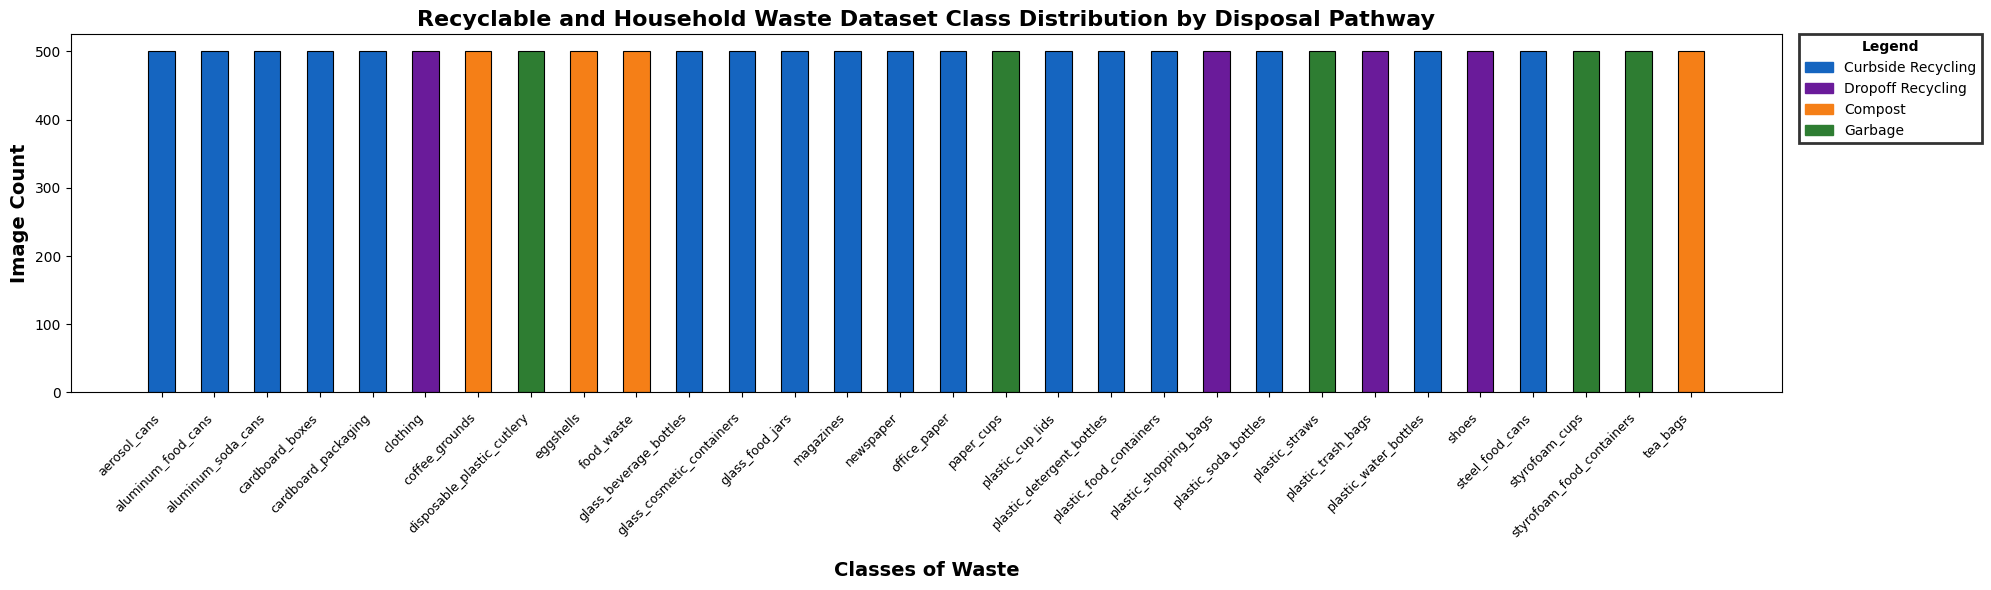

In [25]:
#==============-
# Bar Chart View
# ==============

# Initalize dictionary mapping disposal pathways to color for the legend
PATHWAY_COLORS = {
    'curbside_recycling': '#1565C0',
    'dropoff_recycling':  '#6A1B9A',
    'compost':            '#F57F17',
    'garbage':            '#2E7D32',
    'UNMAPPED':           '#B71C1C',
}

# Display class distribution in bar chart
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(df['class'], df['count'], width=0.5,
       color=[PATHWAY_COLORS.get(p, '#B71C1C') for p in df['pathway']],
       edgecolor='black', linewidth=0.8)

ax.set_xticks(range(len(df['class'])))
ax.set_xticklabels(df['class'], rotation=45, ha='right', fontsize=9)
ax.tick_params(axis='x', pad=10)

ax.set_xlabel('Classes of Waste', fontweight='bold', fontsize=14, labelpad=15)
ax.set_ylabel('Image Count', fontweight='bold', fontsize=14)
ax.set_title('Recyclable and Household Waste Dataset Class Distribution by Disposal Pathway', fontweight='bold', fontsize=16)

legend = ax.legend(
    handles=[mpatches.Patch(color=c, label=p.replace('_', ' ').title())
             for p, c in PATHWAY_COLORS.items() if p in df['pathway'].values],
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    title='Legend',
    title_fontproperties={'weight': 'bold', 'size': 10},
    frameon=True,
    edgecolor='black',
    fancybox=False,
)
legend.get_frame().set_linewidth(2)

# Plot bar chart and save image to Waste Classification Dataset Audit
plt.tight_layout()
plt.savefig(DATASET_AUDIT_PATH / 'class_distribution_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

Both the table and bar graph should that the dataset is well balanced: every class has roughly the same number of images and there are no missing or unmapped classes. 

It's important to note that two classes: `carboard_boxes` and `carboard_packaging` might contain similar looking items, which may cause some confusion for our model during training. 

### 1.5 Split Dataset into Train/Val/Test

We will now split the data into three directories: **train (70%)**, **validation (15%)**, and **test (15%)**. Moreover, we will further split the test images into two subfolders (`test_default/` and `test_real_world/`) so we can measure the domain gap between types of images when evaluating the results of our model.

In [26]:
# Clear old splits if they exist so we always start from scratch
if SPLITS_PATH.exists():
    shutil.rmtree(SPLITS_PATH)
    print("Cleared old splits")

# Walk every class and assign images to train, val, or test
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name

    images = [f for f in class_dir.rglob("*") if f.is_file()]
    if len(images) < 10:
        print(f"WARNING: {class_name} only has {len(images)} images, skipping")
        continue

    train_imgs, temp    = train_test_split(images, test_size=0.30, random_state=SEED)
    val_imgs, test_imgs = train_test_split(temp,   test_size=0.50, random_state=SEED)

    for split, imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
        split_dir = SPLITS_PATH / split / class_name
        split_dir.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            # Prefix with the parent subfolder name to avoid filename collisions
            unique_name = f"{img.parent.name}_{img.name}"
            shutil.copy2(img, split_dir / unique_name)

            # Mirror test images into subcategory directories for the default vs real-world evaluation in section 2.8
            if split == "test":
                subcat_dir = SPLITS_PATH / f"test_{img.parent.name}" / class_name
                subcat_dir.mkdir(parents=True, exist_ok=True)
                shutil.copy2(img, subcat_dir / unique_name)

print("Split dataset into train/val/test. Further split test into test_default and test_real_world.")


Cleared old splits
Train/val/test splits written to disk


## Step 2: Train the Stage A: the Base Waste Classifier

### 2.1 Load Split Datasets

No we will load the three split directories into TensorFlow datasets. Each image is resized to 224 by 224 and grouped into batches of 32. Additionally, we store images into memory after the first epoch so we don't have to load them every time and load the next batch on the CPU while the GPU is training to save resources.

In [27]:
AUTOTUNE = tf.data.AUTOTUNE

'''
Load split datasets from disk into TensorFlow datasets
Images are resized to 224x224 pixels and grouped into batches of 32
label_mode='categorical' returns one-hot labels required by CategoricalCrossentropy
'''

# Training Dataset - train
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Validation Dataset - val
val_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset - test
test_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset of Default Images - test_default
test_default_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test_default'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset of Real World Images - test_real_world
test_real_world_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test_real_world'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names) # Sets number of neurons in Dense layer to 30
print(f"\nNumber of classes: {NUM_CLASSES}")
print(f"Classes: {class_names}")

# Images are stored in memory after first epoch so they don't get re-read every time
train_ds           = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) # Images shuffled in train set
val_ds             = val_ds.cache().prefetch(buffer_size=AUTOTUNE)  # Loads next batch on CPU
test_ds            = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_default_ds    = test_default_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_real_world_ds = test_real_world_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 10500 files belonging to 30 classes.
Found 2250 files belonging to 30 classes.
Found 2250 files belonging to 30 classes.
Found 1140 files belonging to 30 classes.
Found 1110 files belonging to 30 classes.
Number of classes: 30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']


### 2.2 Apply Data Augmentation Techniques

Data augmentation prevents the model from memorising specific orientations or lighting conditions. This prevents the model from overfitting, where it memorizes training images rather than learning genuine patterns among images of the same class. We will use 6 data augmentation techniques for training our model:

| Technique | What it does |
|---|---|
| `RandomRotation(30/360)` | Rotates the image up to ±30° |
| `RandomZoom(0.2)` | Zooms in or out by up to 20% |
| `RandomTranslation(0.15, 0.15)` | Shifts the image up to 15% in any direction |
| `RandomFlip("horizontal_and_vertical")` | Randomly mirrors the image left-right and/or top-bottom |
| `RandomBrightness(0.15)` | Randomly lightens or darkens the image by up to 15% |
| `RandomContrast(0.15)` | Randomly increases or decreases contrast by up to 15% |

In [ ]:
#==============-
# Data Augmentation Pipeline
# ==============

# Stack the 6 augmentation layers into a single Sequential block so we can drop
# it inside the model graph in section 2.3. Augmentation runs only during
# training; Keras automatically disables it at evaluation time.
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=30/360),            # Rotates up to +/- 30 degrees
    layers.RandomZoom(height_factor=0.2),            # Zooms in or out up to 20%
    layers.RandomTranslation(height_factor=0.15,
                             width_factor=0.15),     # Shifts up to 15% in any direction
    layers.RandomFlip("horizontal_and_vertical"),    # Mirrors left-right and top-bottom
    layers.RandomBrightness(factor=0.15),            # Lightens or darkens by up to 15%
    layers.RandomContrast(factor=0.15),              # Increases or decreases contrast by up to 15%
], name="augmentation")


### 2.3 Build the Stage A Base Waste Classifier

Now that we have an augmentation pipeline in place, we can build the Stage A: Base Waste Classifier. Stage A is a transfer learning model built on top of **EfficientNetV2-S**, a pretrained convolutional neural network that has already learned how to recognise low level visual features (edges, colors, textures, shapes) from millions of ImageNet photos. By starting from those weights instead of training from scratch, our model picks up waste-specific patterns much faster and with far less data than it would otherwise need.

The backbone is frozen during the first phase of training so that only the classification head learns. The head takes the backbone's feature map, pools it down to a single vector, runs it through a dropout-protected 256-unit dense layer with L2 regularization, and finishes with a softmax over the 30 waste classes. Dropout and L2 are both there to discourage overfitting on the smaller waste dataset.

| Layer | Output Shape | Trainable Params |
|-|-|-|
| Input | (None, 224, 224, 3) | 0 |
| Augmentation | (None, 224, 224, 3) | 0 |
| EfficientNetV2-S (frozen) | (None, 7, 7, 1280) | 0 |
| GlobalAveragePooling2D | (None, 1280) | 0 |
| BatchNormalization | (None, 1280) | 5,120 |
| Dropout(0.3) | (None, 1280) | 0 |
| Dense(256, Swish + L2) | (None, 256) | 327,936 |
| Dropout(0.2) | (None, 256) | 0 |
| Dense(30, Softmax) | (None, 30) | 7,710 |

We also define two helper classes here that get used by both Stage A and Stage B during training: `WarmupCosineSchedule` (a custom learning rate schedule used in Phase 2) and `freeze_batchnorm` (a function that locks BatchNormalization layers during fine-tuning). Both are explained inline in the code cell below.

In [ ]:
#==============-
# Helper Classes
# ==============

class WarmupCosineSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup from start_lr to peak_lr, then cosine decay to end_lr.

    Used in Phase 2 of both Stage A and Stage B to smooth out the accuracy dip
    that usually happens when a frozen backbone gets suddenly fine-tuned with a
    moderate learning rate. The warmup gives the new gradients a few hundred
    steps to settle before the cosine portion starts cooling the rate back down.
    """
    def __init__(self, start_lr, peak_lr, end_lr, warmup_steps, total_steps):
        super().__init__()
        self.start_lr     = float(start_lr)
        self.peak_lr      = float(peak_lr)
        self.end_lr       = float(end_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.start_lr + (self.peak_lr - self.start_lr) * (step / self.warmup_steps)
        decay_progress = (step - self.warmup_steps) / max(self.total_steps - self.warmup_steps, 1.0)
        decay_progress = tf.clip_by_value(decay_progress, 0.0, 1.0)
        cosine = 0.5 * (1.0 + tf.cos(math.pi * decay_progress))
        decayed_lr = self.end_lr + (self.peak_lr - self.end_lr) * cosine
        return tf.where(step < self.warmup_steps, warmup_lr, decayed_lr)

    def get_config(self):
        return {
            "start_lr":     self.start_lr,
            "peak_lr":      self.peak_lr,
            "end_lr":       self.end_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps":  self.total_steps,
        }


def freeze_batchnorm(model):
    """Set every BatchNormalization layer to non-trainable.

    Keras keeps BN layers updating their running mean and variance whenever the
    parent model is trainable. During fine-tuning that disrupts the pretrained
    feature statistics and causes a sharp accuracy drop right after unfreezing.
    Freezing BN keeps the backbone behaving the way it did during the head
    warmup so the loss curve climbs smoothly through the transition.
    """
    for layer in model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


#==============-
# Build Stage A
# ==============

def build_stage_a(num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)                    # Apply augmentation defined in 2.2

    # EfficientNetV2-S has rescaling and normalization baked in, so raw [0,255]
    # pixel values feed straight in without any preprocessing call. 21M params,
    # 83.9% ImageNet top-1.
    base_model = EfficientNetV2S(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model._name = "stage_a_backbone"             # Stable name for the lookup in Stage B
    base_model.trainable = False                      # Frozen for Phase 1; Phase 2 will unfreeze the top half

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="swish",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs, outputs, name="stage_a")
    return model, base_model


model_a, base_model = build_stage_a(NUM_CLASSES)
model_a.summary()


### 2.4 Define Training Callbacks

Before we kick off training, we need to define the callbacks that monitor the training run and adjust it on the fly. Stage A trains in two phases (Phase 1 freezes the backbone and warms up the head, Phase 2 fine-tunes the top half of the backbone), and each phase needs a slightly different set of callbacks. The table below summarizes what each one does and where it is used.

| Callback | Where | Monitors | What It Does |
|-|-|-|-|
| `ModelCheckpoint` | both phases | `val_accuracy` | Saves the best weights to disk whenever validation accuracy improves |
| `EarlyStopping` | both phases | `val_accuracy` | Stops training after several epochs of no improvement and rolls the model back to the best weights it has seen |
| `ReduceLROnPlateau` | Phase 1 only | `val_loss` | Halves the learning rate when validation loss stalls, giving the model a finer step to escape the plateau |
| `WarmupCosineSchedule` | Phase 2 only | step count | Linear warmup to a small peak learning rate, then cosine decay to a near-zero floor (defined as a helper class in section 2.3) |

Only the `ModelCheckpoint` is shared between phases, so we define it once here. The other callbacks get instantiated inline inside the training cell because their patience and learning rate parameters differ between Phase 1 and Phase 2.

In [ ]:
#==============-
# Shared Checkpoint Callback
# ==============

# Saves the best val_accuracy across both training phases into a single .keras
# file. The phase-specific EarlyStopping and ReduceLROnPlateau callbacks live
# inline in the training cell because each phase tunes them differently.
checkpoint_cb = ModelCheckpoint(
    str(MODELS_PATH / "stage_a_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)


### 2.5 Stage A Model Training

Now we can train Stage A. The training happens in two phases. In Phase 1, the EfficientNetV2-S backbone stays frozen and only the new classification head learns; this is fast because almost all the weights are locked, and it gets the new head into a reasonable starting point without disturbing the pretrained features. In Phase 2, we unfreeze the top half of the backbone and let it adapt slightly to waste imagery using a warmup-cosine learning rate that peaks at 1e-4. Every BatchNormalization layer in the backbone stays in inference mode for Phase 2 to stop its running statistics from drifting on the small fine-tune batches, which is the trick that prevents the usual accuracy dip when a frozen backbone is unfrozen. Wall-clock on Kaggle T4 is roughly **XX minutes**.

In [ ]:
#==============-
# Phase 1: Warm Up the Head
# ==============

# Backbone fully frozen, only the new classification head trains. Fast convergence.
print("Phase 1 - warming up head (backbone frozen)")
base_model.trainable = False
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # Smoothing softens the one-hot targets
    metrics=["accuracy"],
)

PHASE1_EPOCHS = 15
history_p1 = model_a.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        checkpoint_cb,
        EarlyStopping(monitor="val_accuracy", patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-4, verbose=1),
    ],
    verbose=1,
)
phase1_epochs_run = len(history_p1.history["accuracy"])  # Remember how many epochs Phase 1 actually ran

#==============-
# Phase 2: Fine-Tune the Top Half of the Backbone
# ==============

# Unfreeze the top half of the backbone but keep BatchNorm in inference mode.
# Freezing BN stops it from drifting on the small fine-tune batches, which is
# what keeps the accuracy curve climbing through the transition rather than dipping.
print("\nPhase 2 - fine-tuning top half of backbone (BN frozen, cosine LR)")
base_model.trainable = True
total_layers   = len(base_model.layers)
unfreeze_from  = total_layers // 2
for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False                          # Bottom half stays frozen
freeze_batchnorm(base_model)                         # Every BN layer locked

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"  unfrozen backbone layers: {trainable_count} of {total_layers}")

PHASE2_EPOCHS   = 25
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
total_steps     = int(steps_per_epoch) * PHASE2_EPOCHS
warmup_steps    = int(steps_per_epoch) * 3           # 3-epoch warmup before cosine decay kicks in

lr_schedule = WarmupCosineSchedule(
    start_lr=1e-6,
    peak_lr=1e-4,
    end_lr=1e-6,
    warmup_steps=warmup_steps,
    total_steps=total_steps,
)
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

history_p2 = model_a.fit(
    train_ds,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        checkpoint_cb,
        EarlyStopping(monitor="val_accuracy", patience=8,
                      restore_best_weights=True, verbose=1),
    ],
    verbose=1,
)

#==============-
# Merge Phase 1 and Phase 2 Histories
# ==============

# Stitch the two history dicts together so plotting code in section 2.6 sees a
# single continuous curve. Only the keys present in both phases get merged
# (Phase 2 omits learning_rate logging because of the schedule object).
class _History:
    pass
history_a = _History()
shared_keys = history_p1.history.keys() & history_p2.history.keys()
history_a.history = {
    k: history_p1.history[k] + history_p2.history[k]
    for k in shared_keys
}
print(f"\nPhase 1 ran {phase1_epochs_run} epochs; "
      f"Phase 2 ran {len(history_p2.history['accuracy'])} epochs")
print(f"Best Stage A checkpoint saved to: {MODELS_PATH / 'stage_a_best.keras'}")


### 2.6 Plot Training vs Validation Error Metrics

With Stage A trained, the first thing we want to check are the training and validation accuracy and loss curves over time. These curves are a quick sanity check before we evaluate on the test set. The dashed grey vertical line marks the switch from Phase 1 (frozen backbone) to Phase 2 (top half of backbone fine-tuned). With BatchNorm frozen during Phase 2, the curve should climb smoothly through the transition rather than dipping. A widening gap between the train and validation curves at the end of training would be a sign of overfitting.

In [ ]:
#==============-
# Accuracy and Loss Curves
# ==============

epochs = range(1, len(history_a.history["accuracy"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs, history_a.history["accuracy"],     label="Train Accuracy", color="steelblue")
ax1.plot(epochs, history_a.history["val_accuracy"], label="Val Accuracy",   color="tomato")
ax1.axvline(phase1_epochs_run + 0.5, color="grey", linestyle="--", linewidth=1, label="Unfreeze")  # Phase 1 -> Phase 2 marker
ax1.set_title("Stage A Training vs Validation Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs, history_a.history["loss"],     label="Train Loss", color="steelblue")
ax2.plot(epochs, history_a.history["val_loss"], label="Val Loss",   color="tomato")
ax2.axvline(phase1_epochs_run + 0.5, color="grey", linestyle="--", linewidth=1, label="Unfreeze")
ax2.set_title("Stage A Training vs Validation Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Stage A Base Waste Classifier Error Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / "stage_a_error_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.7 Evaluate Stage A on the Test Set

Now we run the best Stage A checkpoint on the held-out test set and report per-class accuracy, precision, recall, and F1 score for each of the 30 classes. The classes are sorted by accuracy in descending order so the strongest and weakest performers are easy to spot. The macro average at the bottom gives the overall picture across all 30 classes.

In [ ]:
#==============-
# Table View
# ==============

from sklearn.metrics import precision_score, recall_score, f1_score

# Load the best checkpoint with compile=False so the custom WarmupCosineSchedule
# does not need to be reconstructed for inference
best_model_a = tf.keras.models.load_model(MODELS_PATH / 'stage_a_best.keras', compile=False)

# Run predictions on full test set
all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = best_model_a.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot labels to integer class indices

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Build the confusion matrix and pull per-class accuracy off the diagonal
cm = confusion_matrix(all_labels, all_preds)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
sorted_indices     = np.argsort(per_class_accuracy)[::-1]   # Descending so the top performers are at the top

report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Print classification report sorted by per-class accuracy in descending order
print("Stage A Classification Report")
print("=" * 75)
print(f"{'Class':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 75)
for i in sorted_indices:
    name = class_names[i]
    acc  = per_class_accuracy[i]
    p    = report[name]['precision']
    r    = report[name]['recall']
    f1   = report[name]['f1-score']
    sup  = int(report[name]['support'])
    print(f"{name:<35} {acc:>9.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {sup:>9}")
print("-" * 75)
print(f"{'macro avg':<35} {np.mean(per_class_accuracy):>9.4f} {report['macro avg']['precision']:>10.4f} {report['macro avg']['recall']:>8.4f} {report['macro avg']['f1-score']:>8.4f} {int(report['macro avg']['support']):>9}")


In [ ]:
#==============-
# Bar Chart View
# ==============

# Calculate Per-Class Metrics
per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

# Calculate average accuracy, precision, recall and F1
avg_accuracy  = np.mean(per_class_accuracy)
avg_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
avg_recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
avg_f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# Sort classes by descending accuracy with the average bar pinned to the front of the chart
sorted_labels    = ['Average'] + [class_names[i] for i in sorted_indices]
sorted_accuracy  = [avg_accuracy]  + [per_class_accuracy[i]  for i in sorted_indices]
sorted_precision = [avg_precision] + [per_class_precision[i] for i in sorted_indices]
sorted_recall    = [avg_recall]    + [per_class_recall[i]    for i in sorted_indices]
sorted_f1        = [avg_f1]        + [per_class_f1[i]        for i in sorted_indices]

x     = np.arange(len(sorted_labels))
width = 0.2

# Plot grouped bar chart with one bar per metric per class
fig, ax = plt.subplots(figsize=(24, 7))
ax.bar(x - 1.5*width, sorted_accuracy,  width, label='Accuracy',  color='steelblue',   edgecolor='black', linewidth=0.8)
ax.bar(x - 0.5*width, sorted_precision, width, label='Precision', color='tomato',      edgecolor='black', linewidth=0.8)
ax.bar(x + 0.5*width, sorted_recall,    width, label='Recall',    color='seagreen',    edgecolor='black', linewidth=0.8)
ax.bar(x + 1.5*width, sorted_f1,        width, label='F1 Score',  color='mediumpurple', edgecolor='black', linewidth=0.8)

ax.set_title('Stage A Base Waste Classifier Per-Class Metrics', fontsize=16, fontweight='bold')
ax.set_xlabel('Class of Waste', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_per_class_metrics.png', dpi=150, bbox_inches='tight')  # Save to Stage A Results
plt.show()

# Print overall metric summary
print(f"\nOverall Metrics")
print(f"{'='*40}")
print(f"Accuracy:  {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall:    {avg_recall:.4f}")
print(f"F1 Score:  {avg_f1:.4f}")


Stage A reaches an overall test accuracy of **XX.X%** with a macro-average F1 of **XX.X%**. Strong performers (>90% F1) tend to be visually distinctive items such as **XX**, **XX**, and **XX**, where the shape, color and texture are unique enough that the model rarely confuses them. Weaker performers (<70% F1) are typically items that look very similar to other classes, such as **XX** vs **XX** or **XX** vs **XX**. We will revisit this in section 2.10 where we measure accuracy at the disposal pathway level instead of the class level, which is the metric that ultimately matters for the user.

### 2.8 Default vs Real World Test Set Evaluation

Each class in the dataset has both `default` photos (clean, product-style backgrounds) and `real_world` photos (in-the-wild, varied lighting and backgrounds). To understand how well Stage A generalises beyond studio conditions, we run the model on each subcategory separately and compare the per-class accuracy. The Vercel dashboard takes photos from a phone camera in arbitrary lighting, so the real-world subcategory is the more honest predictor of deployed performance.

In [ ]:
#==============-
# Default vs Real World Evaluation
# ==============

# Helper that runs predictions on a dataset and returns predicted and true class indices
def evaluate_subcategory(model, dataset):
    preds, labels = [], []
    for images, label_batch in dataset:
        batch_preds = model.predict(images, verbose=0)
        preds.extend(np.argmax(batch_preds, axis=1))
        labels.extend(np.argmax(label_batch.numpy(), axis=1))  # Convert one-hot to integer class indices
    return np.array(preds), np.array(labels)

preds_default, labels_default = evaluate_subcategory(best_model_a, test_default_ds)
preds_real,    labels_real    = evaluate_subcategory(best_model_a, test_real_world_ds)

# Compute per-class accuracy for each subcategory
def per_class_acc(labels, preds):
    cm_sub  = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    row_sum = cm_sub.sum(axis=1)
    row_sum[row_sum == 0] = 1                       # Avoid division by zero for any empty class
    return cm_sub.diagonal() / row_sum

acc_default = per_class_acc(labels_default, preds_default)
acc_real    = per_class_acc(labels_real,    preds_real)

#==============-
# Table View
# ==============

# Print overall accuracy for each subcategory
print(f"Default    Overall Accuracy: {acc_default.mean():.4f}")
print(f"Real World Overall Accuracy: {acc_real.mean():.4f}")
print(f"Domain Gap:                  {acc_default.mean() - acc_real.mean():+.4f}")

# Print per-class comparison table sorted by real_world accuracy ascending so the
# weakest real-world classes show up at the top
sorted_by_real = np.argsort(acc_real)
print(f"\n{'Class':<35} {'Default':>9} {'Real World':>11} {'Gap':>8}")
print("-" * 66)
for i in sorted_by_real:
    gap = acc_default[i] - acc_real[i]
    print(f"{class_names[i]:<35} {acc_default[i]:>9.4f} {acc_real[i]:>11.4f} {gap:>+8.4f}")

#==============-
# Bar Chart View
# ==============

# Sort ascending so the highest real_world accuracy is at the top of the horizontal chart
sort_idx       = np.argsort(acc_real)
sorted_names   = [class_names[i] for i in sort_idx]
sorted_default = [acc_default[i] * 100 for i in sort_idx]
sorted_real    = [acc_real[i]    * 100 for i in sort_idx]

y      = np.arange(len(sorted_names))
height = 0.35

fig, ax = plt.subplots(figsize=(14, 12))
ax.barh(y - height/2, sorted_default, height, label='Default',    color='steelblue', edgecolor='black', linewidth=0.5)
ax.barh(y + height/2, sorted_real,    height, label='Real World', color='tomato',    edgecolor='black', linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Stage A Per-Class Accuracy: Default vs Real World', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_default_vs_real_world.png', dpi=150, bbox_inches='tight')  # Save to Stage A Results
plt.show()


Stage A reaches **XX.X%** accuracy on the default subcategory and **XX.X%** on the real-world subcategory, for a domain gap of **XX.X percentage points**. A gap here is expected because in-the-wild photos have busy backgrounds, partial occlusion, and unpredictable lighting that augmentation alone cannot fully simulate. Since the Vercel dashboard takes phone camera photos in real lighting, the real-world number is the more honest predictor of how the model will behave once deployed.

### 2.9 Confusion Matrices

To better understand where Stage A is failing, we plot two confusion matrices:

1. A **30-class confusion matrix** that shows which classes the model confuses with which other classes. Most off-diagonal mass is expected to land inside disposal-pathway clusters (one type of paper confused for another type of paper, one type of metal can confused for another), which is much less harmful than a cross-pathway mistake.
2. A **disposal-pathway confusion matrix** that collapses the 30-class predictions down to the four disposal pathways. This is the matrix that matters most for our user-facing decision because it shows whether the model picks the right bin, even when it gets the specific class slightly wrong.

In [ ]:
#==============-
# Class-level Confusion Matrix
# ==============

# Normalize the class confusion matrix so each row sums to 1, which makes the
# colors comparable across classes regardless of their support count
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 6},
    vmin=0,
    vmax=1
)

# Plot 30-class confusion matrix and save it to Stage A Results
ax.set_title('Stage A Base Waste Classifier Confusion Matrix (30 Classes)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_confusion_matrix_classes.png', dpi=150, bbox_inches='tight')
plt.show()

#==============-
# Disposal Pathway Confusion Matrix
# ==============

# Collapse the 30 class predictions down to the four disposal pathways using DISPOSAL_MAP
PATHWAY_ORDER  = ['curbside_recycling', 'dropoff_recycling', 'compost', 'garbage']
PATHWAY_LABELS = [p.replace('_', ' ').title() for p in PATHWAY_ORDER]

pathway_true = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_labels]
pathway_pred = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_preds]

cm_pathway      = confusion_matrix(pathway_true, pathway_pred, labels=PATHWAY_ORDER)
cm_pathway_norm = cm_pathway.astype(float) / cm_pathway.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_pathway_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=PATHWAY_LABELS,
    yticklabels=PATHWAY_LABELS,
    ax=ax,
    linewidths=1,
    annot_kws={'size': 12},
    vmin=0,
    vmax=1
)

# Plot pathway-level confusion matrix and save it to Stage A Results
ax.set_title('Stage A Base Waste Classifier Confusion Matrix (Disposal Pathways)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Pathway', fontsize=14)
ax.set_ylabel('True Pathway', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_confusion_matrix_pathways.png', dpi=150, bbox_inches='tight')
plt.show()


The pathway-level matrix is significantly cleaner than the 30-class matrix. Most class-level mistakes happen between items that share a disposal pathway (different types of paper, different metal cans, different glass containers), so they do not affect the final decision the user actually sees. This is exactly what motivates the adjusted-accuracy chart in section 2.10.

### 2.10 Plot Adjusted Accuracy Bar Chart

Adjusted accuracy counts a prediction as correct if the predicted class and the true class map to the same disposal pathway, even when they are different classes. For example, if the model labels a `plastic_soda_bottle` as a `plastic_water_bottle`, both classes map to `curbside_recycling`, so the user still ends up putting the item in the right bin and the prediction counts as correct. This is the metric that matches what our users actually care about: *did the item end up in the right bin?*

In [ ]:
#==============-
# Adjusted Accuracy Calculation
# ==============

# Adjusted accuracy: a prediction counts as correct if the predicted class and
# the true class share a disposal pathway, even when the specific class differs
adjusted_correct = np.zeros(NUM_CLASSES)
class_counts     = np.zeros(NUM_CLASSES)

for true_idx, pred_idx in zip(all_labels, all_preds):
    true_pathway = DISPOSAL_MAP.get(class_names[true_idx], 'UNMAPPED')
    pred_pathway = DISPOSAL_MAP.get(class_names[pred_idx], 'UNMAPPED')
    class_counts[true_idx] += 1
    if true_pathway == pred_pathway:
        adjusted_correct[true_idx] += 1

adj_acc_per_class = adjusted_correct / class_counts

#==============-
# Bar Chart View
# ==============

# Sort by original accuracy ascending so the highest performers sit at the top of the chart
sort_idx     = np.argsort(per_class_accuracy)
sorted_names = [class_names[i] for i in sort_idx]
sorted_orig  = [per_class_accuracy[i] * 100 for i in sort_idx]
sorted_adj   = [adj_acc_per_class[i]  * 100 for i in sort_idx]

y = np.arange(len(sorted_names))

fig, ax = plt.subplots(figsize=(12, 12))

# Draw adjusted accuracy bars first so the darker original bars sit on top
ax.barh(y, sorted_adj,  color='#A8D5A2', label='Adjusted Accuracy', edgecolor='black', linewidth=0.5)
ax.barh(y, sorted_orig, color='#2E7D32', label='Original Accuracy', edgecolor='black', linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy: Original vs Adjusted (City of Phoenix Policy)', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

legend = ax.legend(
    loc='lower right',
    frameon=True,
    edgecolor='black',
    fancybox=False,
    fontsize=10
)
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.savefig(STAGE_A_RESULTS_PATH / 'stage_a_adjusted_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Print overall accuracy comparison so the size of the pathway-level gain is obvious
overall_orig = per_class_accuracy.mean()
overall_adj  = adjusted_correct.sum() / class_counts.sum()
print(f"Original Accuracy: {overall_orig:.4f}")
print(f"Adjusted Accuracy: {overall_adj:.4f}")
print(f"Pathway Gain:      {overall_adj - overall_orig:+.4f}")


Adjusted accuracy is **XX percentage points** higher than raw class accuracy, which confirms that most of Stage A's remaining errors are within-pathway confusions that do not affect the deployed decision. In other words, even when Stage A picks the wrong specific class, it usually still picks a class that lives in the right bin. This is the result we want from a model that is going to be making real disposal decisions for end users.

## Step 3: Prepare Synthetic Recyclable Contamination Dataset

Stage B needs labeled examples of *contaminated* recyclables, but no public dataset has anything close to the scale that this project needs. So instead, we build one synthetically. The idea is simple: take clean recyclable photos from our Step 1 dataset, segment the object, paste random contamination textures (food residue, grease, mold, paint, etc.) onto the object surface, and save the result alongside the unmodified clean original. Each source image produces 1 clean copy and 8 contaminated copies (one per texture type), so the final dataset has a known 1:8 clean-to-contaminated ratio that we will correct for with class weights during training.

### 3.1 Install Dependencies

Step 3 needs two extra Python packages that are not in Kaggle's default TensorFlow image: `rembg` (for U2-Net background segmentation, used to find the object inside each photo) and `pillow-avif-plugin` (a few of our texture files ship in AVIF format and Pillow cannot read them without it). The `-q` flag keeps the install output short so the cell stays readable.

In [ ]:
!pip install -q "rembg[gpu]" pillow-avif-plugin


### 3.2 Import Libraries

Step 3 uses a handful of modules on top of what Step 0 already imported. `rembg` runs the U2-Net segmentation model, `scipy.ndimage` handles the morphological cleanup of the alpha mask, `PIL.ImageFilter` is used for the texture compositing, and `tqdm` gives us a progress bar for the long generation loop.

In [ ]:
import io
import math

from rembg import remove, new_session
from scipy import ndimage

from PIL import ImageFilter
from tqdm import tqdm


### 3.3 Initialise the rembg Session

We load the U2-Net background-removal model once at the start of Step 3 and reuse the session across every image. The session caches the model weights so we are not paying the load cost on every call. Without this, the generation loop would re-load roughly 30 MB of weights for each of the 1,000 source images.

In [ ]:
REMBG_SESSION = new_session('u2netp')                # Reused across every source image in section 3.8
print("U2-Net session initialised")


### 3.4 Configure Paths and Constants

A few constants for Step 3:
- `TEXTURE_PATH` points to the [Waste Contamination Textures Dataset](https://www.kaggle.com/datasets/ragbag84/waste-contamination-textures-dataset) on Kaggle, which contains the contamination texture images we composite onto each source.
- `STAGE_B_PATH` is where the intermediate generation output lands before we package the final dataset in section 3.11.
- `MAX_IMAGES = 1000` caps how many source images get processed. With 9 outputs per source the full Stage B dataset is 9,000 images, which trains in roughly 25 minutes on a Kaggle T4.
- `CONTAMINATION_LEVELS` maps human-readable severity labels (light, medium, heavy) to a patch count. More patches means heavier visible contamination.
- `RECYCLABLE_CLASSES` filters the 30-class disposal map down to just the recyclable classes, since contamination is only a deciding factor for recyclables (you would never call a banana peel "contaminated").

In [ ]:
#==============-
# Paths and Constants for Step 3
# ==============

TEXTURE_PATH  = Path("/kaggle/input/datasets/ragbag84/waste-contamination-textures-dataset/Contamination Textures Dataset/textures")
STAGE_B_PATH  = Path("/kaggle/working/Stage B Dataset")
TEXTURE_CACHE = Path("/kaggle/working/texture_cache")
DATASET_ROOT  = Path("/kaggle/working/Synthetic Recyclable Contamination Dataset")

# Cap source images per Stage B run. 1000 sources times 9 outputs per source
# gives a 9000 image dataset that trains in roughly 25 minutes on Kaggle T4.
MAX_IMAGES = 1000

# Severity level to patch count map. More patches means heavier visible contamination.
CONTAMINATION_LEVELS = {
    "light":  1,
    "medium": 2,
    "heavy":  3,
}

# Filter the 30-class disposal map down to just the recyclable classes since
# contamination is only a deciding factor for recyclables
RECYCLABLE_CLASSES = [
    cls for cls, pathway in DISPOSAL_MAP.items()
    if pathway in ("curbside_recycling", "dropoff_recycling")
]


### 3.5 Build the Contamination Texture Pool

Before we can paste contamination onto source images, we need to scan the texture dataset and group every texture image by the contaminant type it represents. The pool ends up as a dictionary mapping contaminant type to a list of texture file paths.

#### 3.5.1 Discover Contaminant Types and Texture Images

In [ ]:
#==============-
# Build the Contamination Texture Pool
# ==============

# Walk every subfolder of TEXTURE_PATH and group texture image paths by the
# contaminant type they represent. Skips any cached _nobg.png files since those
# get regenerated by load_texture in section 3.6.2.
def build_texture_pool(texture_path: Path) -> dict:
    pool = {}
    for contaminant_dir in sorted(texture_path.iterdir()):
        if not contaminant_dir.is_dir():
            continue
        textures = sorted(
            f for f in contaminant_dir.iterdir()
            if f.suffix.lower() == '.png'
            and '_nobg' not in f.stem
        )
        if textures:
            pool[contaminant_dir.name] = textures
    return pool

texture_pool = build_texture_pool(TEXTURE_PATH)

# Print summary of discovered contaminant types and image counts
print(f"Discovered {len(texture_pool)} contaminant types")
for contaminant, textures in texture_pool.items():
    print(f"  {contaminant:<25} {len(textures)} images")


#### 3.5.2 Display Texture Pool Summary

In [ ]:
#==============-
# Texture Pool Summary
# ==============

# Print every texture file grouped by contaminant type for a full inventory view
total = sum(len(v) for v in texture_pool.values())
print(f"Contamination Texture Library")
print(f"{'='*50}")
for contaminant, textures in texture_pool.items():
    print(f"\n  {contaminant}")
    for t in textures:
        print(f"    {t.name}")
print(f"\n{'='*50}")
print(f"Total: {len(texture_pool)} types, {total} images")


The pool contains exactly 8 contaminant types and around 40 texture images in total. The 8 types will become the contamination subgroup labels for Stage B in Step 4, alongside the `clean` label, for a 9-class softmax.

### 3.6 Define Image Processing Functions

Three helper functions do the heavy lifting in the generation loop in section 3.8. We define them separately here so each one can be tested or swapped independently without touching the loop itself: `get_object_mask` for segmentation, `load_texture` for cached texture loading, and `apply_texture_patch` for the actual compositing.

#### 3.6.1 Object Segmentation

`get_object_mask` runs U2-Net on the source image and returns a soft alpha mask for the object. A small morphological closing fills any tiny interior holes left by transparent or reflective surfaces (glass bottles are notorious for this), and a Gaussian blur feathers the edges of the mask so the contamination patch fades naturally at the object boundary instead of cutting off sharply.

In [ ]:
#==============-
# Object Segmentation Helper
# ==============

def get_object_mask(img: np.ndarray) -> np.ndarray:
    """
    Runs U2-Net on the input image and returns a soft alpha mask for the
    object. The mask is cleaned up with a morphological closing (to fill small
    holes in transparent or reflective surfaces) and then feathered with a
    Gaussian blur so contamination patches fade naturally at the boundary
    instead of cutting off sharply.
    """
    buf = io.BytesIO()
    Image.fromarray(img).save(buf, format='PNG')
    output = remove(buf.getvalue(), session=REMBG_SESSION)
    alpha  = np.array(Image.open(io.BytesIO(output)).convert('RGBA'))[:, :, 3]
    alpha  = alpha.astype(np.float32) / 255.0
    # Fill small interior holes left by transparent or reflective surfaces
    binary = ndimage.binary_closing(
        alpha > 0.5, structure=np.ones((5, 5))
    ).astype(np.float32)
    # Feather edges so composited contamination fades at the object boundary
    return ndimage.gaussian_filter(binary, sigma=2)


#### 3.6.2 Texture Loading

`load_texture` opens a texture file and removes its background, then caches the result on disk so we are not paying the rembg cost on every reuse. The cache lives under `/kaggle/working` because `/kaggle/input` is read-only. If a PNG texture already has a transparency channel we skip the rembg call entirely.

In [ ]:
#==============-
# Texture Loading Helper
# ==============

def load_texture(texture_path: Path) -> np.ndarray:
    """
    Loads a texture image with its background removed and caches the result on
    disk so the rembg call is paid at most once per texture file. The cache
    lives under /kaggle/working since /kaggle/input is read-only. PNG textures
    that already have transparency skip the rembg call entirely.
    """
    # Cache lives in /kaggle/working since /kaggle/input is read-only
    cache_path = TEXTURE_CACHE / texture_path.parent.name / (texture_path.stem + '_nobg.png')
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists():
        return np.array(Image.open(cache_path).convert('RGBA'))

    ext           = texture_path.suffix.lower()
    needs_removal = True

    if ext == '.png':
        rgba = np.array(Image.open(texture_path).convert('RGBA'))
        # If the alpha channel already has transparency, use it directly
        if rgba[:, :, 3].min() < 255:
            needs_removal = False

    if needs_removal:
        with open(texture_path, 'rb') as f:
            output = remove(f.read(), session=REMBG_SESSION)
        rgba = np.array(Image.open(io.BytesIO(output)).convert('RGBA'))

    Image.fromarray(rgba).save(cache_path)
    return rgba


#### 3.6.3 Texture Patch Application

`apply_texture_patch` pastes a single texture patch onto a random anchor point inside the object mask. Before pasting, the texture is randomly rotated, scaled, flipped horizontally and vertically, and alpha-blended with the underlying pixels so that every contaminated copy looks different even when the same texture file is reused. The three-way weight (texture alpha times object mask times opacity scalar) is what keeps the contamination from spilling outside the object boundary.

In [ ]:
#==============-
# Texture Patch Application Helper
# ==============

def apply_texture_patch(
    base_img:     np.ndarray,
    texture_rgba: np.ndarray,
    object_mask:  np.ndarray,
    alpha:        float = 0.6,
) -> np.ndarray:
    """
    Pastes a single texture patch onto a random anchor point inside the object
    mask. Before pasting, the texture is randomly rotated, scaled, flipped, and
    alpha-blended so that every contaminated copy looks different even when the
    same texture file is reused. The three-way weight (texture alpha times
    object mask times opacity scalar) keeps the contamination from spilling
    outside the object boundary.
    """
    H, W = base_img.shape[:2]

    # Sample a random anchor point from within the object region
    obj_ys, obj_xs = np.where(object_mask > 0.3)
    if len(obj_ys) == 0:
        return base_img
    idx = random.randint(0, len(obj_ys) - 1)
    cy, cx = int(obj_ys[idx]), int(obj_xs[idx])

    # Augment the texture so repeated reuse of the same texture file looks different each time
    tex = Image.fromarray(texture_rgba, 'RGBA')
    tex = tex.rotate(random.uniform(0, 360), expand=True)
    scale = random.uniform(0.25, 0.60)
    tex = tex.resize((max(1, int(W * scale)), max(1, int(H * scale))), Image.LANCZOS)
    if random.random() > 0.5:
        tex = tex.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        tex = tex.transpose(Image.FLIP_TOP_BOTTOM)

    tex_arr = np.array(tex)
    th, tw  = tex_arr.shape[:2]

    # Compute placement coordinates centered on the anchor
    x1, y1 = cx - tw // 2, cy - th // 2
    x2, y2 = x1 + tw, y1 + th

    # Clip to image bounds so the texture patch never reaches outside the canvas
    ix1, iy1 = max(0, x1), max(0, y1)
    ix2, iy2 = min(W, x2), min(H, y2)

    if ix2 <= ix1 or iy2 <= iy1:
        return base_img

    sx1 = ix1 - x1
    sy1 = iy1 - y1
    sx2 = sx1 + (ix2 - ix1)
    sy2 = sy1 + (iy2 - iy1)
    tex_slice = tex_arr[sy1:sy2, sx1:sx2]

    # Three-way weight: texture alpha x object mask x opacity scalar
    tex_a  = tex_slice[:, :, 3].astype(np.float32) / 255.0
    obj_a  = object_mask[iy1:iy2, ix1:ix2]
    weight = tex_a * obj_a * alpha

    # Composite the texture into the base image
    result  = base_img.astype(np.float32)
    region  = result[iy1:iy2, ix1:ix2]
    tex_rgb = tex_slice[:, :, :3].astype(np.float32)
    result[iy1:iy2, ix1:ix2] = (
        region * (1 - weight[..., np.newaxis]) + tex_rgb * weight[..., np.newaxis]
    )
    return np.clip(result, 0, 255).astype(np.uint8)


### 3.7 Build the Output Directory Structure

Wipe any old Stage B dataset and recreate the directory tree from scratch. `clean/{class}/` will hold the unmodified clean copies and `contaminated/{contaminant}/{level}/` will hold the synthetically contaminated copies grouped by texture type and severity level. The directory structure mirrors how the generation loop in section 3.8 will write the files.

In [ ]:
#==============-
# Build Output Directory Structure
# ==============

# Clear any old Stage B Dataset directory so we always start from a clean state
if STAGE_B_PATH.exists():
    shutil.rmtree(STAGE_B_PATH)
    print("Cleared existing Stage B Dataset directory")

# Pre-create the contaminated subdirectory tree so the generation loop in
# section 3.8 can write directly without checking existence on every image
for contaminant in texture_pool:
    for level in CONTAMINATION_LEVELS:
        (STAGE_B_PATH / 'contaminated' / contaminant / level).mkdir(parents=True, exist_ok=True)

print("Output directory structure created")
print(f"  {STAGE_B_PATH / 'contaminated'}")


### 3.8 Run the Generation Pipeline

This is the main generation loop. We stratified-sample 1,000 source images across every recyclable class proportional to its size. For each source image, we save 1 clean copy, run object segmentation once (the expensive call), then loop the 8 texture types and produce 1 contaminated copy per type with a randomly chosen severity (light, medium, or heavy). Total output is **9,000 images** per run. Wall-clock on Kaggle T4 is roughly **XX minutes**.

In [ ]:
#==============-
# Clear Texture Cache
# ==============

# Clear the texture cache so load_texture rebuilds it with fresh background
# removal applied. Skip if the cache directory does not exist yet.
import shutil
if TEXTURE_CACHE.exists():
    shutil.rmtree(TEXTURE_CACHE)
    print(f"Cleared texture cache: {TEXTURE_CACHE}")
else:
    print("No cache to clear.")


In [ ]:
#==============-
# Source Image Selection
# ==============

records           = []
contaminant_types = sorted(texture_pool.keys())
assert len(contaminant_types) == 8, \
    f"Expected 8 contaminant types, found {len(contaminant_types)}: {contaminant_types}"

# Collect every source image grouped by class so we can stratified-sample
images_by_class = {}
for cls in RECYCLABLE_CLASSES:
    cls_dir = DATASET_PATH / cls
    if not cls_dir.exists():
        print(f"WARNING: {cls} not found, skipping")
        continue
    images_by_class[cls] = sorted(p for p in cls_dir.rglob("*") if p.is_file())

# Allocate the 1000-image quota proportional to each class's share of the pool
total_available = sum(len(v) for v in images_by_class.values())
target_total    = min(MAX_IMAGES, total_available)
rng             = np.random.default_rng(SEED)

selected = []
for cls, files in images_by_class.items():
    share = round(target_total * len(files) / total_available)
    share = min(share, len(files))
    if share == 0:
        continue
    idx = rng.choice(len(files), size=share, replace=False)
    selected.extend((cls, files[i]) for i in idx)

# Trim or top up to hit target_total exactly (rounding can drift by a couple)
if len(selected) > target_total:
    selected = selected[:target_total]
elif len(selected) < target_total:
    needed = target_total - len(selected)
    leftover = [(cls, f) for cls, files in images_by_class.items() for f in files
                if (cls, f) not in set(selected)]
    selected.extend(rng.choice(leftover, size=min(needed, len(leftover)), replace=False).tolist())

random.Random(SEED).shuffle(selected)
n_sources = len(selected)
print(f"Sources : {n_sources:,}")
print(f"Expected outputs: {n_sources * 9:,} ({n_sources:,} clean + {n_sources * 8:,} contaminated)")
print(f"Textures: {contaminant_types}")
print()

#==============-
# Generation Loop
# ==============

for class_name, img_path in tqdm(selected, desc="Generating"):
    source_stem = f"{img_path.parent.name}_{img_path.stem}"

    base_img = np.array(
        Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    )

    # Save the clean copy first so even if the contamination step fails we still have the unmodified source
    clean_dir  = STAGE_B_PATH / "clean" / class_name
    clean_dir.mkdir(parents=True, exist_ok=True)
    clean_path = clean_dir / f"{source_stem}.png"
    Image.fromarray(base_img).save(clean_path, format="PNG")

    records.append({
        "image_path":   str(clean_path),
        "label":        "clean",
        "subgroup":     "none",
        "level":        "none",
        "source_class": class_name,
        "source_stem":  source_stem,
    })

    # rembg is the expensive call; run it once per source then reuse the mask for every contaminated variant
    mask = get_object_mask(base_img)

    # One contaminated copy for every texture type with severity picked randomly
    for contaminant_type in contaminant_types:
        textures = texture_pool[contaminant_type]
        level    = random.choice(list(CONTAMINATION_LEVELS.keys()))
        n_patches = CONTAMINATION_LEVELS[level]

        result_img = base_img.copy()
        for _ in range(n_patches):
            tex_path = random.choice(textures)
            texture  = load_texture(tex_path)
            alpha    = random.uniform(0.45, 0.75)
            result_img = apply_texture_patch(result_img, texture, mask, alpha=alpha)

        cont_dir  = STAGE_B_PATH / "contaminated" / contaminant_type / level
        cont_dir.mkdir(parents=True, exist_ok=True)
        cont_path = cont_dir / f"{source_stem}_{contaminant_type}_{level}.png"
        Image.fromarray(result_img).save(cont_path, format="PNG")

        records.append({
            "image_path":   str(cont_path),
            "label":        "contaminated",
            "subgroup":     contaminant_type,
            "level":        level,
            "source_class": class_name,
            "source_stem":  source_stem,
        })

print(f"\nGenerated {len(records):,} images")


### 3.9 Build the Stage B Manifest

The manifest is a CSV file with one row per generated image. It records the file path, the binary label (clean or contaminated), the contaminant subgroup, the severity level, the source recyclable class, and a stable `source_stem` that links each contaminated copy back to its clean original. The `source_stem` is what lets Step 4 build a leak-free train/val/test split where every contaminated sibling of a clean image stays in the same split.

In [ ]:
#==============-
# Build and Save the Stage B Manifest
# ==============

# Write the manifest CSV with one row per generated image. The source_stem
# column is what Step 4 uses to keep clean and contaminated siblings of the
# same source image in the same train/val/test split.
df_stage_b = pd.DataFrame(records)

manifest_path = STAGE_B_PATH / 'stage_b_manifest.csv'
df_stage_b.to_csv(manifest_path, index=False)

print(f"Manifest saved to {manifest_path}")
print(f"Total images: {len(df_stage_b):,}")
print(f"\nSample rows:")
print(df_stage_b.head(8).to_string(index=False))


### 3.10 Audit the Dataset

Before we start training Stage B, we want a few quick sanity checks on the generated dataset. Are the labels balanced as expected (1:8 clean to contaminated)? Are the 8 contaminant types each represented in roughly equal numbers? Are the severity levels distributed evenly across light, medium, and heavy? And do the contaminated copies actually *look* contaminated when we eyeball them?

#### 3.10.1 Label Distribution

In [ ]:
#==============-
# Label Distribution
# ==============

# Count clean vs contaminated and print percentages so the 1:8 ratio is obvious
label_counts = df_stage_b['label'].value_counts()

print("Label Distribution")
print("=" * 40)
for label, count in label_counts.items():
    pct = count / len(df_stage_b) * 100
    print(f"  {label:<20} {count:>7,}  ({pct:.1f}%)")
print("-" * 40)
print(f"  {'Total':<20} {len(df_stage_b):>7,}")


#### 3.10.2 Subgroup Distribution

A breakdown of how many contaminated images each of the 8 contaminant types produced. Counts should be close to even since the generation loop emits one of each per source image.

In [ ]:
#==============-
# Subgroup Distribution
# ==============

# Filter to only the contaminated rows and break them down by contaminant type.
# Counts should be roughly even since the generation loop emits one of each per source.
contaminated_df = df_stage_b[df_stage_b['label'] == 'contaminated']
subgroup_counts = contaminated_df['subgroup'].value_counts().sort_index()

print("Subgroup Distribution (contaminated images only)")
print("=" * 50)
for subgroup, count in subgroup_counts.items():
    pct = count / len(contaminated_df) * 100
    print(f"  {subgroup:<28} {count:>7,}  ({pct:.1f}%)")
print("-" * 50)
print(f"  {'Total':<28} {len(contaminated_df):>7,}")


#### 3.10.3 Level Distribution

Light, medium, and heavy severities should each appear in roughly a third of the contaminated rows because the loop picks severity uniformly at random for each contaminated copy.

In [ ]:
#==============-
# Level Distribution
# ==============

# Light, medium, and heavy should each be roughly a third since severity is
# picked uniformly at random per contaminated copy in section 3.8
level_counts = contaminated_df['level'].value_counts()
level_order  = ['light', 'medium', 'heavy']

print("Level Distribution (contaminated images only)")
print("=" * 40)
for level in level_order:
    count = level_counts.get(level, 0)
    pct   = count / len(contaminated_df) * 100
    print(f"  {level:<20} {count:>7,}  ({pct:.1f}%)")
print("-" * 40)
print(f"  {'Total':<20} {len(contaminated_df):>7,}")


#### 3.10.4 Summary Bar Charts

Three charts side by side: the overall clean vs contaminated label distribution, the contaminant type distribution, and the severity level distribution. All three should match the printed tables in 3.10.1 to 3.10.3.

In [ ]:
#==============-
# Summary Bar Charts
# ==============

# Three subplots side by side covering label, subgroup and severity distributions
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Label distribution
axes[0].bar(label_counts.index, label_counts.values, color=['#2196F3', '#E53935'], width=0.4)
axes[0].set_title('Label Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Label', fontsize=10)
axes[0].set_ylabel('Image Count', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 50, f"{count:,}", ha='center', fontsize=9)

# Plot 2: Subgroup distribution
axes[1].bar(subgroup_counts.index, subgroup_counts.values, color='#8E44AD', width=0.6)
axes[1].set_title('Contamination Subgroup Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Contaminant Type', fontsize=10)
axes[1].set_ylabel('Image Count', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Level distribution
level_vals   = [level_counts.get(l, 0) for l in level_order]
level_colors = ['#81C784', '#FFA726', '#E53935']
axes[2].bar(level_order, level_vals, color=level_colors, width=0.4)
axes[2].set_title('Contamination Level Distribution', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Level', fontsize=10)
axes[2].set_ylabel('Image Count', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)
for i, count in enumerate(level_vals):
    axes[2].text(i, count + 50, f"{count:,}", ha='center', fontsize=9)

plt.suptitle('Stage B Contamination Dataset Audit', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Save audit chart into the Synthetic dataset folder so it ships with the dataset
DATASET_ROOT.mkdir(parents=True, exist_ok=True)
audit_chart_path = DATASET_ROOT / 'dataset_audit.png'
plt.savefig(audit_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {audit_chart_path}")


#### 3.10.5 Visual Sample Audit

Five random source images shown twice: clean on top, contaminated on the bottom. This is the eyeball check that the texture patches actually landed on the object surface and that the resulting contaminated copies look plausible to a human.

In [ ]:
#==============-
# Visual Sample Audit
# ==============

# Grab 5 random clean and 5 random contaminated samples for a side-by-side
# eyeball check that the synthetic contamination actually looks plausible
clean_rows = df_stage_b[df_stage_b['label'] == 'clean'].reset_index(drop=True)
cont_rows  = df_stage_b[df_stage_b['label'] == 'contaminated'].reset_index(drop=True)

n = min(5, len(clean_rows), len(cont_rows))
clean_sample = clean_rows.iloc[random.sample(range(len(clean_rows)), n)]
cont_sample  = cont_rows.iloc[random.sample(range(len(cont_rows)), n)]
pairs = list(zip(clean_sample.itertuples(), cont_sample.itertuples()))

# Display 2-row grid: clean images on top, contaminated images on bottom
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col, (clean_row, cont_row) in enumerate(pairs):
    axes[0, col].imshow(Image.open(clean_row.image_path).convert('RGB'))
    axes[0, col].axis('off')
    axes[0, col].set_title(f"clean{clean_row.source_class}", fontsize=7.5,
                            color='#2196F3', fontweight='bold', pad=4)

    axes[1, col].imshow(Image.open(cont_row.image_path).convert('RGB'))
    axes[1, col].axis('off')
    axes[1, col].set_title(f"contaminated {cont_row.subgroup} | {cont_row.level} {cont_row.source_class}",
        fontsize=7.5, color='#E53935', fontweight='bold', pad=4
    )

# Row labels on the left edge of the figure
fig.text(0.01, 0.73, 'Clean',        va='center', rotation='vertical', fontsize=11, fontweight='bold', color='#2196F3')
fig.text(0.01, 0.27, 'Contaminated', va='center', rotation='vertical', fontsize=11, fontweight='bold', color='#E53935')

plt.suptitle('Stage B Dataset Visual Sample Audit - Matched Pairs', fontsize=13, fontweight='bold')
plt.tight_layout()

# Save into the Synthetic dataset folder so it ships with the dataset
visual_audit_path = DATASET_ROOT / 'visual_sample_audit.png'
plt.savefig(visual_audit_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {visual_audit_path}")


### 3.11 Save Synthetic Recyclable Contamination Dataset

Copy every generated image into a single tree under `Synthetic Recyclable Contamination Dataset/images/` (split into `clean_recyclables/` and `contaminated_recyclables/` subfolders) and rewrite the manifest with paths relative to that root. This is the final directory layout Step 4 reads from. We also zip the whole thing for easy download so the dataset can be reused without re-running the generation pipeline.

In [ ]:
#==============-
# Build the Final Dataset Directory
# ==============

IMAGES_ROOT = DATASET_ROOT / 'images'
CLEAN_DIR   = IMAGES_ROOT / 'clean_recyclables'
CONTAM_DIR  = IMAGES_ROOT / 'contaminated_recyclables'

# Reset the final dataset directory so we always start from a clean state
if IMAGES_ROOT.exists():
    shutil.rmtree(IMAGES_ROOT)
IMAGES_ROOT.mkdir(parents=True)

#==============-
# Copy Clean Images
# ==============

# Flatten {class}/default/Image_N.png to {class}/default_Image_N.png so both
# sides sit at the same directory depth
print("Copying clean images...")
total_clean = 0
for cls in tqdm(RECYCLABLE_CLASSES):
    src_cls = DATASET_PATH / cls
    dst_cls = CLEAN_DIR / cls
    if not src_cls.exists():
        print(f"  WARNING: {cls} not found - skipping")
        continue
    for f in src_cls.rglob('*'):
        if not f.is_file():
            continue
        flat_name = f"{f.parent.name}_{f.name}"
        dst_file  = dst_cls / flat_name
        dst_file.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(f, dst_file)
        total_clean += 1

#==============-
# Copy Contaminated Images
# ==============

print("\nCopying contaminated images...")
total_contam = 0
for img_file in tqdm(list((STAGE_B_PATH / 'contaminated').rglob('*.png'))):
    cls      = img_file.parent.name
    dst_file = CONTAM_DIR / cls / img_file.name
    dst_file.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(img_file, dst_file)
    total_contam += 1

#==============-
# Rewrite the Manifest with Relative Paths
# ==============

# Switch image_path to paths relative to the dataset root so the CSV works
# outside the original Kaggle session
df_manifest = pd.read_csv(STAGE_B_PATH / 'stage_b_manifest.csv')

def to_relative_path(row):
    p = Path(row['image_path'])
    if row['label'] == 'clean':
        # Mirror the flattening applied above: {subfolder}_{filename}
        flat = f"{p.parent.name}_{p.name}"
        return f"images/clean_recyclables/{row['source_class']}/{flat}"
    return f"images/contaminated_recyclables/{row['source_class']}/{p.name}"

df_manifest['image_path'] = df_manifest.apply(to_relative_path, axis=1)
df_manifest.to_csv(DATASET_ROOT / 'stage_b_manifest.csv', index=False)

#==============-
# Clean Up Intermediate Directory
# ==============

# We no longer need the intermediate Stage B Dataset directory once the final
# dataset and manifest are assembled
if STAGE_B_PATH.exists():
    shutil.rmtree(STAGE_B_PATH)
    print(f"\nRemoved intermediate directory: {STAGE_B_PATH}")

#==============-
# Zip the Final Dataset
# ==============

zip_base = WORKING_PATH / 'Synthetic Recyclable Contamination Dataset'
zip_path = Path(shutil.make_archive(str(zip_base), 'zip', root_dir=str(DATASET_ROOT)))
print(f"Zipped dataset to {zip_path}")

#==============-
# Summary
# ==============

print(f"\nFinal directory structure:")
print(f"Synthetic Recyclable Contamination Dataset/")
print(f"|- stage_b_manifest.csv")
print(f"|- dataset_audit.png")
print(f"|- visual_sample_audit.png")
print(f"\\- images/")
print(f"    |- clean_recyclables/        {total_clean:>6,} images across {len(list(CLEAN_DIR.iterdir()))} classes")
print(f"    \\- contaminated_recyclables/ {total_contam:>6,} images across {len(list(CONTAM_DIR.iterdir()))} classes")


## Step 4: Train Stage B, the Contamination Classifier

Stage B is the second model in our pipeline. Its job is to look at any recyclable item that Stage A flagged for a recycling bin and decide whether it is actually clean enough to be recycled, or whether contamination should redirect it to garbage. Stage B sits on top of the Stage A backbone (so it inherits all the visual features Stage A learned) and only replaces the final classification head with a new 9-class softmax that distinguishes clean from each of the 8 contaminant types.

### 4.1 Load and Split the Stage B Dataset

Before loading the Stage B dataset, we free the Stage A artifacts from memory so Stage B has room to load alongside them. Then we build a *source-aware* 70/15/15 split. The split happens on unique source stems (not on individual files), so every clean copy and its 8 contaminated siblings always end up in the same split. Without this, the model could see a clean copy in training and the contaminated copy of the same object in validation, which would inflate the validation score without actually generalising.

Labels are encoded for a 9-class softmax: class 0 is `clean` and classes 1 through 8 are the 8 contaminant types in alphabetical order.

In [ ]:
#==============-
# Load and Resolve the Stage B Manifest
# ==============

import os, glob as _glob

# Load the manifest CSV that section 3.11 wrote out
_csv = DATASET_ROOT / 'stage_b_manifest.csv'
manifest_b = pd.read_csv(_csv)

# Build a filename to real-path index for every file on disk. The manifest
# stores paths relative to DATASET_ROOT and we resolve them by basename so the
# resolver works even if the directory layout shifts slightly.
_file_index = {}
for root, dirs, files in os.walk(str(DATASET_ROOT)):
    for fname in files:
        _file_index[fname] = os.path.join(root, fname)

# Explicit glob for clean_recyclables in case it is a symlink that os.walk skips
clean_dir = str(DATASET_ROOT / 'images' / 'clean_recyclables')
for f in _glob.glob(os.path.join(clean_dir, '**', '*'), recursive=True):
    if os.path.isfile(f):
        _file_index[os.path.basename(f)] = f

print(f"Indexed {len(_file_index)} files on disk")

def _resolve(p):
    # Direct basename match first
    basename = os.path.basename(p)
    if basename in _file_index:
        return os.path.realpath(_file_index[basename])
    # Fallback for clean images: the manifest prefixed the source class name
    # onto the filename but the on-disk file does not have that prefix
    parts = p.replace('\\', '/').split('/')
    if 'clean_recyclables' in parts:
        source_class = parts[-2]
        prefix = source_class + '_'
        if basename.startswith(prefix):
            stripped = basename[len(prefix):]
            if stripped in _file_index:
                return os.path.realpath(_file_index[stripped])
    return str(DATASET_ROOT / p)

manifest_b['image_path'] = manifest_b['image_path'].apply(_resolve)
found = manifest_b['image_path'].apply(os.path.exists).sum()
print(f"Resolved {found} / {len(manifest_b)} paths")

#==============-
# 9-class Label Encoding
# ==============

# Class 0 is clean, classes 1 through 8 are the 8 contaminant types in alphabetical order
stage_b_class_names = ['clean'] + sorted(manifest_b[manifest_b['subgroup'] != 'none']['subgroup'].unique())
print(f"Stage B classes ({len(stage_b_class_names)}): {stage_b_class_names}")
label_map = {c: i for i, c in enumerate(stage_b_class_names)}
manifest_b['label_idx'] = manifest_b['subgroup'].map(lambda s: label_map.get(s if s != 'none' else 'clean'))
NUM_STAGE_B_CLASSES = len(stage_b_class_names)

# Used by Stage B inference and by the McNemar test in Step 5
CLEAN_CLASS_IDX = 0
class_names_b   = stage_b_class_names

#==============-
# Source-aware Train / Val / Test Split (70 / 15 / 15)
# ==============

# Split on unique source stems instead of individual files so a clean copy and
# its 8 contaminated siblings of the same source always sit in the same split.
# Without this, the model could memorise the contamination textures by seeing
# matched pairs across splits and the val score would be inflated.
rng = np.random.RandomState(SEED)
stems = manifest_b[['source_stem', 'source_class']].drop_duplicates()

train_stems, val_stems, test_stems = [], [], []
for cls, grp in stems.groupby('source_class'):
    idx = rng.permutation(len(grp))
    n_val  = max(1, int(len(grp) * 0.15))
    n_test = max(1, int(len(grp) * 0.15))
    s = grp['source_stem'].iloc[idx].tolist()
    test_stems  += s[:n_test]
    val_stems   += s[n_test:n_test + n_val]
    train_stems += s[n_test + n_val:]

train_df_b = manifest_b[manifest_b['source_stem'].isin(train_stems)].reset_index(drop=True)
val_df_b   = manifest_b[manifest_b['source_stem'].isin(val_stems)].reset_index(drop=True)
test_df_b  = manifest_b[manifest_b['source_stem'].isin(test_stems)].reset_index(drop=True)

print(f"Unique sources : train={len(train_stems)}  val={len(val_stems)}  test={len(test_stems)}")
print(f"Total images   : train={len(train_df_b)}  val={len(val_df_b)}  test={len(test_df_b)}")

#==============-
# tf.data Pipeline
# ==============

AUTOTUNE = tf.data.AUTOTUNE

def _load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label

def _build_ds(df, shuffle=False):
    # Drop any rows whose image_path cannot be read so tf.data never hits a missing file mid-training
    mask = df["image_path"].apply(os.path.exists)
    if (~mask).any():
        print(f"  Dropping {(~mask).sum()} unreadable paths (keeping {mask.sum()} / {len(df)})")
        df = df[mask].reset_index(drop=True)
    ds = tf.data.Dataset.from_tensor_slices((df["image_path"].values, df["label_idx"].values))
    if shuffle:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_b_ds = _build_ds(train_df_b, shuffle=True)
val_b_ds   = _build_ds(val_df_b).cache()
test_b_ds  = _build_ds(test_df_b).cache()


### 4.2 Data Augmentation

Stage B reuses the same augmentation pipeline that was defined in section 2.2 for Stage A. Augmentation lives inside the model graph and is automatically disabled at evaluation time, so we do not need a separate code cell here. The same rotation, zoom, translation, flip, brightness, and contrast augmentations apply to every Stage B training image.

### 4.3 Build the Stage B Contamination Classifier

Stage B reuses the trained Stage A backbone (the part of the model that already knows what waste items look like) and replaces only the classification head. The new head outputs 9 probabilities: one for clean and one for each of the 8 contaminant types. The backbone stays frozen during Phase 1 so Stage B can converge quickly on the contamination task without disturbing the features Stage A already learned.

| Layer | Output Shape | Trainable Params |
|-|-|-|
| Input | (None, 224, 224, 3) | 0 |
| Augmentation | (None, 224, 224, 3) | 0 |
| EfficientNetV2-S backbone (frozen) | (None, 7, 7, 1280) | 0 |
| GlobalAveragePooling2D | (None, 1280) | 0 |
| BatchNormalization | (None, 1280) | 5,120 |
| Dropout(0.3) | (None, 1280) | 0 |
| Dense(256, Swish + L2) | (None, 256) | 327,936 |
| Dropout(0.2) | (None, 256) | 0 |
| Dense(9, Softmax) | (None, 9) | 2,313 |

In [ ]:
#==============-
# Build Stage B on top of Stage A
# ==============

def build_stage_b(stage_a_weights_path):
    """
    Loads the trained Stage A model, extracts its EfficientNet backbone, and
    attaches a new 9-class classification head for contamination detection.
    The Stage A model is discarded after the backbone is extracted to free
    memory before Stage B training begins.
    """
    # compile=False skips deserializing the custom WarmupCosineSchedule, which is not needed for inference
    stage_a = tf.keras.models.load_model(stage_a_weights_path, compile=False)
    # Find the EfficientNet backbone inside the loaded Stage A model. The
    # substring match works for both EfficientNetB0 and EfficientNetV2S regardless
    # of which one Stage A was originally trained with.
    backbone = next(
        l for l in stage_a.layers
        if isinstance(l, tf.keras.Model) and "efficientnet" in l.name.lower()
    )
    backbone.trainable = False                       # Frozen for Phase 1

    inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = data_augmentation(inputs)              # Reuse the augmentation pipeline from section 2.2
    x       = backbone(x, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    x       = layers.Dense(256, activation="swish",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_STAGE_B_CLASSES, activation="softmax",
                           name="contamination")(x)
    model   = Model(inputs, outputs, name="stage_b")

    # Free the loaded Stage A model since we only needed the backbone reference
    del stage_a
    gc.collect()
    return model, backbone


model_b, backbone_b = build_stage_b(MODELS_PATH / "stage_a_best.keras")
model_b.summary()


### 4.4 Define Callbacks

Stage B uses the same two-phase callback layout as Stage A: a shared `ModelCheckpoint` for saving the best val_accuracy weights, plus phase-specific `EarlyStopping`, `ReduceLROnPlateau` (Phase 1 only) and `WarmupCosineSchedule` learning rate schedule (Phase 2 only). Only the checkpoint callback is shared, so that is the only one we define up front here.

In [ ]:
#==============-
# Shared Checkpoint Callback for Stage B
# ==============

# Saves the best val_accuracy across both Stage B phases into a single .keras
# file. Phase-specific EarlyStopping and ReduceLROnPlateau live inline in 4.5
# because each phase needs different patience and learning rate parameters.
checkpoint_b_cb = ModelCheckpoint(
    str(MODELS_PATH / "stage_b_best.keras"),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)


### 4.5 Stage B Model Training

Stage B training mirrors Stage A. Phase 1 (12 epochs) trains only the new contamination head on top of the frozen Stage A backbone. Phase 2 (up to 18 epochs) unfreezes the top third of the backbone with BatchNormalization frozen and uses a warmup-cosine schedule that peaks at a small **5e-5** learning rate. Class weights compensate for the natural 1-clean to 1-of-each-of-8-contaminants ratio (where clean is overrepresented 8 times). Adam uses a `clipnorm` of 1.0 as cheap insurance against any residual gradient spikes from the synthetic texture composites.

In [ ]:
#==============-
# Class Weights for Stage B
# ==============

# Clean appears in every source while each contaminant only appears in 1 out of
# every 8 contaminated copies. Balanced class weights restore equal influence
# per class during training so the model does not just learn to predict clean.
cw_values = compute_class_weight(
    "balanced",
    classes=np.arange(NUM_STAGE_B_CLASSES),
    y=train_df_b["label_idx"].values,
)
class_weights_b = dict(enumerate(cw_values))
print("Class weights:", {class_names_b[k]: round(v, 2) for k, v in class_weights_b.items()})

#==============-
# Phase 1: Warm Up the Contamination Head
# ==============

print("\nPhase 1 - warming up contamination head (backbone frozen)")
backbone_b.trainable = False
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),   # clipnorm protects against gradient spikes from synthetic textures
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

PHASE1_EPOCHS_B = 12
history_b_p1 = model_b.fit(
    train_b_ds,
    epochs=PHASE1_EPOCHS_B,
    validation_data=val_b_ds,
    class_weight=class_weights_b,
    callbacks=[
        checkpoint_b_cb,
        EarlyStopping(monitor="val_accuracy", patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-4, verbose=1),
    ],
    verbose=1,
)
phase1_epochs_b_run = len(history_b_p1.history["accuracy"])

#==============-
# Phase 2: Fine-Tune the Top Third of the Backbone
# ==============

print("\nPhase 2 - fine-tuning top third of backbone (BN frozen, cosine LR)")
backbone_b.trainable = True
total_layers_b  = len(backbone_b.layers)
unfreeze_from_b = int(total_layers_b * 2 / 3)
for layer in backbone_b.layers[:unfreeze_from_b]:
    layer.trainable = False                          # Bottom two-thirds stay frozen
freeze_batchnorm(backbone_b)                         # Same BN trick as Stage A

trainable_count_b = sum(1 for l in backbone_b.layers if l.trainable)
print(f"  unfrozen backbone layers: {trainable_count_b} of {total_layers_b}")

PHASE2_EPOCHS_B   = 18
steps_per_epoch_b = tf.data.experimental.cardinality(train_b_ds).numpy()
total_steps_b     = int(steps_per_epoch_b) * PHASE2_EPOCHS_B
warmup_steps_b    = int(steps_per_epoch_b) * 2       # 2-epoch warmup before cosine decay kicks in

lr_schedule_b = WarmupCosineSchedule(
    start_lr=1e-6,
    peak_lr=5e-5,                                    # Lower peak than Stage A since the backbone is already well-fitted
    end_lr=5e-7,
    warmup_steps=warmup_steps_b,
    total_steps=total_steps_b,
)
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule_b, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_b_p2 = model_b.fit(
    train_b_ds,
    epochs=PHASE2_EPOCHS_B,
    validation_data=val_b_ds,
    class_weight=class_weights_b,
    callbacks=[
        checkpoint_b_cb,
        EarlyStopping(monitor="val_accuracy", patience=6,
                      restore_best_weights=True, verbose=1),
    ],
    verbose=1,
)

#==============-
# Merge Phase 1 and Phase 2 Histories
# ==============

class _History:
    pass
history_b = _History()
shared_keys_b = history_b_p1.history.keys() & history_b_p2.history.keys()
history_b.history = {
    k: history_b_p1.history[k] + history_b_p2.history[k]
    for k in shared_keys_b
}
print(f"\nBest Stage B checkpoint saved to: {MODELS_PATH / 'stage_b_best.keras'}")
print(f"Phase 1 ran {phase1_epochs_b_run} epochs; "
      f"Phase 2 ran {len(history_b_p2.history['accuracy'])} epochs")


### 4.6 Plot Training vs Validation Error Metrics

Accuracy and loss curves for the 9-class contamination head, side by side. The dashed grey vertical line marks the switch from Phase 1 to Phase 2. A widening gap between the train and validation curves means the model is starting to memorise the synthetic textures, which is the failure mode most likely to hurt real-world contamination detection on the deployed dashboard.

In [ ]:
#==============-
# Accuracy and Loss Curves
# ==============

epochs_b = range(1, len(history_b.history["accuracy"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs_b, history_b.history["accuracy"],     label="Train", color="steelblue")
ax1.plot(epochs_b, history_b.history["val_accuracy"], label="Val",   color="tomato")
ax1.axvline(phase1_epochs_b_run + 0.5, color="grey", linestyle="--", linewidth=1, label="Unfreeze")  # Phase 1 -> Phase 2 marker
ax1.set_title("Stage B Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs_b, history_b.history["loss"],     label="Train", color="steelblue")
ax2.plot(epochs_b, history_b.history["val_loss"], label="Val",   color="tomato")
ax2.axvline(phase1_epochs_b_run + 0.5, color="grey", linestyle="--", linewidth=1, label="Unfreeze")
ax2.set_title("Stage B Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Stage B Contamination Classifier Error Metrics",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / "stage_b_error_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.7 Evaluate Stage B on the Test Set

Load the best Stage B checkpoint and report per-class accuracy, precision, recall, and F1 score for all 9 classes. We also compute a binary collapse `P(contaminated) = 1 - P(clean)` along with its ROC-AUC, which is what the downstream dashboard uses for threshold tuning when deciding whether to override a recyclable prediction to garbage.

In [ ]:
#==============-
# Predictions on the Stage B Test Set
# ==============

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

# compile=False skips deserializing the custom WarmupCosineSchedule, which is not needed for inference
best_model_b = tf.keras.models.load_model(MODELS_PATH / "stage_b_best.keras", compile=False)

# Build the aligned probability matrix and label vector for the entire test set
all_b_probs_mat, all_b_labels = [], []
for images, labels in test_b_ds:
    probs = best_model_b.predict(images, verbose=0)
    all_b_probs_mat.extend(probs.tolist())
    all_b_labels.extend(labels.numpy().astype(int).flatten().tolist())

all_b_probs_mat = np.array(all_b_probs_mat)
all_b_labels    = np.array(all_b_labels)
all_b_preds     = np.argmax(all_b_probs_mat, axis=1)

# Binary collapse for the downstream "is it contaminated" decision used by the dashboard
all_b_contam_probs  = 1.0 - all_b_probs_mat[:, CLEAN_CLASS_IDX]
all_b_binary_labels = (all_b_labels != CLEAN_CLASS_IDX).astype(int)

#==============-
# Per-class Metrics
# ==============

cm_b            = confusion_matrix(all_b_labels, all_b_preds,
                                   labels=list(range(NUM_STAGE_B_CLASSES)))
per_class_acc_b = cm_b.diagonal() / cm_b.sum(axis=1).clip(min=1)

rows = []
for i, name in enumerate(class_names_b):
    rows.append({
        "Class":     name,
        "Accuracy":  per_class_acc_b[i],
        "Precision": precision_score(all_b_labels == i, all_b_preds == i, zero_division=0),
        "Recall":    recall_score(all_b_labels == i,    all_b_preds == i, zero_division=0),
        "F1":        f1_score(all_b_labels == i,        all_b_preds == i, zero_division=0),
    })

df_b_metrics = pd.DataFrame(rows)
overall_acc  = (all_b_preds == all_b_labels).mean()
auc_b        = roc_auc_score(all_b_binary_labels, all_b_contam_probs)

print(df_b_metrics.to_string(index=False))
print(f"\nOverall Accuracy : {overall_acc:.4f}")
print(f"Binary ROC-AUC   : {auc_b:.4f}  (clean vs contaminated collapse)")

# Results DataFrame for sections 4.8 and 4.9
results_b               = test_df_b.copy().reset_index(drop=True)
results_b["true_label"] = all_b_labels
results_b["pred_label"] = all_b_preds
results_b["prob"]       = all_b_contam_probs


In [ ]:
#==============-
# Per-class Bar Chart
# ==============

display_names = class_names_b
metric_labels = ["Accuracy", "Precision", "Recall", "F1"]
bar_colors    = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
x             = np.arange(len(display_names))
width         = 0.18

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metric, color) in enumerate(zip(metric_labels, bar_colors)):
    ax.bar(x + i * width, df_b_metrics[metric].values, width,
           label=metric, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(display_names, fontsize=10, rotation=30, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Stage B: Per-Class Evaluation Metrics", fontweight="bold")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / "stage_b_per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.8 Per-Contamination-Level Breakdown

A secondary view that asks how Stage B does on light, medium, and heavy contamination separately. **Flag Rate** is the binary metric (did the model predict any non-clean class for this image?) and **Type Accuracy** is the exact-match metric (did the model also pick the correct specific contaminant type?). We expect heavier contamination to be easier to flag because there is more visible texture for the model to detect.

In [ ]:
#==============-
# Per-Contamination-Level Breakdown
# ==============

# Filter to contaminated rows and compute Flag Rate (any non-clean prediction)
# and Type Accuracy (exact contaminant type match) per severity level
cont_results = results_b[results_b["label"] == "contaminated"].copy()
cont_results["correctly_flagged"] = cont_results["pred_label"] != CLEAN_CLASS_IDX
cont_results["exact_class_match"] = cont_results["pred_label"] == cont_results["true_label"]

level_order = ["light", "medium", "heavy"]
level_rows  = []
for level in level_order:
    lvl_df = cont_results[cont_results["level"] == level]
    if len(lvl_df) == 0:
        continue
    level_rows.append({
        "Level":             level,
        "n":                 len(lvl_df),
        "Flag Rate":         lvl_df["correctly_flagged"].mean(),
        "Type Accuracy":     lvl_df["exact_class_match"].mean(),
    })

df_level = pd.DataFrame(level_rows)
print(df_level.to_string(index=False))

#==============-
# Bar Chart View
# ==============

x      = np.arange(len(df_level))
width  = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, df_level["Flag Rate"].values,     width,
       label="Flag Rate (any contamination)", color="#2196F3")
ax.bar(x + width / 2, df_level["Type Accuracy"].values, width,
       label="Exact Type Accuracy",           color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(df_level["Level"].values)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Stage B: Performance by Contamination Severity", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / "stage_b_by_level.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.9 Per-Recyclable-Class Breakdown

A breakdown of Stage B by the underlying recyclable class. Some classes (cardboard, paper) take texture much more visibly than others (smooth plastic and glass), so we expect Stage B to flag contamination more reliably on some surfaces than on others. The classes most prone to false negatives here are the ones the dashboard threshold needs to be most forgiving about.

In [ ]:
#==============-
# Per-Recyclable-Class Breakdown
# ==============

# For each recyclable source class compute exact 9-class accuracy, clean recall
# (how often the clean copy was correctly labelled clean), and contamination
# flag rate (how often the contaminated copy got pushed off the clean class).
class_rows = []
for cls in sorted(results_b["source_class"].dropna().unique()):
    cls_df   = results_b[results_b["source_class"] == cls]
    clean_df = cls_df[cls_df["label"] == "clean"]
    cont_df  = cls_df[cls_df["label"] == "contaminated"]

    overall_acc = (cls_df["pred_label"] == cls_df["true_label"]).mean()
    clean_acc   = (clean_df["pred_label"] == CLEAN_CLASS_IDX).mean() if len(clean_df) > 0 else float("nan")
    cont_flag   = (cont_df["pred_label"] != CLEAN_CLASS_IDX).mean() if len(cont_df) > 0 else float("nan")

    class_rows.append({
        "Class":          cls,
        "n":              len(cls_df),
        "Exact 9-class":  overall_acc,
        "Clean Recall":   clean_acc,
        "Contam. Flag":   cont_flag,
    })

df_class = (
    pd.DataFrame(class_rows)
    .sort_values("Exact 9-class", ascending=False)
    .reset_index(drop=True)
)
print(df_class.to_string(index=False))

#==============-
# Bar Chart View
# ==============

x     = np.arange(len(df_class))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, df_class["Exact 9-class"], width, label="Exact 9-class",  color="#2196F3")
ax.bar(x,         df_class["Clean Recall"],  width, label="Clean Recall",   color="#4CAF50")
ax.bar(x + width, df_class["Contam. Flag"],  width, label="Contam. Flag",   color="#E53935")

ax.set_xticks(x)
ax.set_xticklabels(df_class["Class"].values, rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Stage B: Performance by Recyclable Class", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(STAGE_B_RESULTS_PATH / "stage_b_by_class.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 5: McNemar's Statistical Test for Stage B

The whole reason Stage B exists is to catch contaminated recyclables that Stage A would otherwise misroute into a recycling bin. But we need to confirm statistically that adding Stage B to the pipeline actually helps, rather than just feeling like it should. McNemar's test asks exactly that question: does the **Full pipeline (Stage A + Stage B)** produce a statistically significant improvement in pathway accuracy compared to **Stage A alone**, or is the difference small enough that it could be explained by random noise?

The test compares two systems on the same set of test images by counting only the **discordant pairs** (images where one system is correct and the other is wrong). The null hypothesis is that the two systems make mistakes at the same rate. If the discordant pairs are heavily lopsided in favour of one system over the other, the null is rejected and we have evidence that one pipeline is genuinely better than the other.

| Outcome | Meaning |
|-|-|
| Stage A correct, Full pipeline correct | Both pipelines agreed (ignored by the test) |
| Stage A correct, Full pipeline wrong | Stage B introduced a false override (a clean recyclable got pushed to garbage) |
| Stage A wrong, Full pipeline correct | Stage B rescued the mistake (a contaminated item correctly got rerouted to garbage) |
| Stage A wrong, Full pipeline wrong | Both pipelines failed (ignored by the test) |

### 5.1 Load the Pathway Test Set

The pathway test set has three folders: 50 clean recyclables, 25 contaminated recyclables, and 25 garbage items, all photographed in real lighting against varied backgrounds. The correct disposal pathway for each folder is fixed: clean recyclables must end up in a recycling pathway (curbside or drop-off), contaminated recyclables must end up in garbage, and garbage stays as garbage. This test set is deliberately small but high-quality so that the McNemar comparison is grounded in realistic photos rather than the synthetic textures that Stage B was trained on.

In [ ]:
#==============-
# Load the Pathway Test Set
# ==============

PATHWAY_TEST_PATH = Path("/kaggle/input/datasets/ragbag84/ecobin-pathway-test-set/Test_Dataset")

# Maps each folder name in the test set to a function that judges whether a
# predicted pathway is correct for that ground truth bucket
TRUTH_CHECKS = {
    "Clean Recyclables":        lambda p: p in {"curbside_recycling", "dropoff_recycling"},
    "Contaminated Recyclables": lambda p: p == "garbage",
    "Garbage":                  lambda p: p == "garbage",
}

# Walk the three subfolders and collect every test image with its ground truth bucket
test_records = []
for bucket, check in TRUTH_CHECKS.items():
    bucket_dir = PATHWAY_TEST_PATH / bucket
    for img_path in sorted(bucket_dir.iterdir()):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            test_records.append({"path": str(img_path), "bucket": bucket})

test_df = pd.DataFrame(test_records)
print(f"Loaded {len(test_df)} test images")
print(test_df["bucket"].value_counts().to_string())


### 5.2 Predict with Both Pipelines

Each test image is run through Stage A alone (predicted class mapped to a disposal pathway via `DISPOSAL_MAP`) and through the Full pipeline (Stage A, then Stage B only if the predicted pathway is recyclable). When Stage B's contamination probability `P(contaminated) = 1 - P(clean)` exceeds the configured threshold, the recyclable pathway is overridden to garbage. The two systems share Stage A's prediction on every image and only differ on the recyclables that Stage B inspects.

In [ ]:
#==============-
# Load Checkpoints and Batch Test Images
# ==============

# compile=False skips deserializing the custom WarmupCosineSchedule, which is not needed for inference
best_model_a = tf.keras.models.load_model(MODELS_PATH / "stage_a_best.keras", compile=False)
best_model_b = tf.keras.models.load_model(MODELS_PATH / "stage_b_best.keras", compile=False)


def load_test_image(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    return np.asarray(img, dtype=np.float32)


# Batch-load every test image into a single tensor for one fast inference call
images = np.stack([load_test_image(p) for p in test_df["path"]], axis=0)
print(f"Test tensor shape: {images.shape}")

#==============-
# Stage A and Full Pipeline Predictions
# ==============

# Stage A: argmax over the 30-class softmax then look up the disposal pathway
probs_a          = best_model_a.predict(images, verbose=0)
pred_class       = [class_names[i] for i in np.argmax(probs_a, axis=1)]
stage_a_pathways = [DISPOSAL_MAP[c] for c in pred_class]

# Stage B: store the raw P(contaminated) = 1 - P(clean) so the threshold sweep
# in section 5.3 can recompute the full pipeline at any cutoff without re-running inference
probs_b       = best_model_b.predict(images, verbose=0)
b_contam_prob = 1.0 - probs_b[:, CLEAN_CLASS_IDX]

STAGE_B_THRESHOLD = 0.5                              # Starting point; the sweep in 5.3 finds the best value
RECYCLABLE = {"curbside_recycling", "dropoff_recycling"}

# Full pipeline pathway: same as Stage A unless Stage A picked a recyclable and
# Stage B's contamination probability exceeds the threshold (override to garbage)
full_pathways = []
for a_path, prob in zip(stage_a_pathways, b_contam_prob):
    if a_path in RECYCLABLE and prob >= STAGE_B_THRESHOLD:
        full_pathways.append("garbage")
    else:
        full_pathways.append(a_path)

#==============-
# Score Each Image Under Both Pipelines
# ==============

test_df["stage_a_pathway"] = stage_a_pathways
test_df["full_pathway"]    = full_pathways
test_df["b_contam_prob"]   = b_contam_prob
test_df["stage_a_correct"] = [TRUTH_CHECKS[b](p) for b, p in zip(test_df["bucket"], test_df["stage_a_pathway"])]
test_df["full_correct"]    = [TRUTH_CHECKS[b](p) for b, p in zip(test_df["bucket"], test_df["full_pathway"])]

acc_a    = test_df["stage_a_correct"].mean()
acc_full = test_df["full_correct"].mean()
print(f"Stage A alone:    {acc_a:.4f}  ({test_df['stage_a_correct'].sum()}/{len(test_df)})")
print(f"Full pipeline:    {acc_full:.4f}  ({test_df['full_correct'].sum()}/{len(test_df)})")


### 5.3 Build the Contingency Table and Run McNemar's Test

The 2 by 2 contingency table counts how often each system was right or wrong on the same image. The two off-diagonal cells (`b` and `c` in classical McNemar notation) are the discordant pairs and they alone drive the test. When the smaller of the two off-diagonals is under 25, statsmodels switches automatically to an exact binomial test instead of the chi-squared approximation, which is what we want at this sample size.

In [ ]:
#==============-
# Contingency Table and McNemar's Test
# ==============

from statsmodels.stats.contingency_tables import mcnemar

# Contingency cells
both_correct = ((test_df["stage_a_correct"]) & (test_df["full_correct"])).sum()
a_only       = ((test_df["stage_a_correct"]) & (~test_df["full_correct"])).sum()   # b cell
full_only    = ((~test_df["stage_a_correct"]) & (test_df["full_correct"])).sum()   # c cell
both_wrong   = ((~test_df["stage_a_correct"]) & (~test_df["full_correct"])).sum()

contingency = np.array([[both_correct, a_only],
                        [full_only,    both_wrong]])

# Use the exact binomial test when discordant pairs are scarce; otherwise the
# chi-squared approximation with continuity correction is fine
discordant = a_only + full_only
use_exact  = discordant < 25
result = mcnemar(contingency, exact=use_exact, correction=not use_exact)

print("Contingency Table")
print("=" * 60)
print(f"{'':<28}{'Full correct':>15}{'Full wrong':>15}")
print(f"{'Stage A correct':<28}{both_correct:>15}{a_only:>15}")
print(f"{'Stage A wrong':<28}{full_only:>15}{both_wrong:>15}")
print("=" * 60)
print(f"Discordant pairs:   {discordant}  (Stage A only: {a_only}, Full only: {full_only})")
print(f"Test method:        {'exact binomial' if use_exact else 'chi-squared with continuity correction'}")
print(f"Test statistic:     {result.statistic:.4f}")
print(f"p-value:            {result.pvalue:.6f}")

ALPHA = 0.05
if result.pvalue < ALPHA:
    direction = "improves" if full_only > a_only else "degrades"
    print(f"Conclusion:         Reject H0 at alpha={ALPHA}. Adding Stage B {direction} pathway accuracy.")
else:
    print(f"Conclusion:         Fail to reject H0 at alpha={ALPHA}. No significant evidence that Stage B changes pathway accuracy.")

#==============-
# Threshold Sweep
# ==============

# Loop over candidate thresholds and rebuild the McNemar discordant counts so
# we can find the cutoff at which Stage B helps the most (largest c - b)
thresholds = np.arange(0.40, 0.96, 0.05)
sweep_rows = []

for t in thresholds:
    full_at_t = np.where(
        (test_df["stage_a_pathway"].isin(RECYCLABLE)) & (test_df["b_contam_prob"] >= t),
        "garbage",
        test_df["stage_a_pathway"],
    )
    full_correct_at_t = np.array([TRUTH_CHECKS[b](p) for b, p in zip(test_df["bucket"], full_at_t)])
    a_correct         = test_df["stage_a_correct"].values

    b_cell = ( a_correct & ~full_correct_at_t).sum()   # Stage A correct, Full wrong
    c_cell = (~a_correct &  full_correct_at_t).sum()   # Stage A wrong, Full correct
    sweep_rows.append({"threshold": round(t, 2), "b": int(b_cell), "c": int(c_cell), "net": int(c_cell - b_cell)})

df_sweep = pd.DataFrame(sweep_rows)
best_row = df_sweep.loc[df_sweep["net"].idxmax()]

print(f"\n{'Threshold':>10} {'b (A better)':>13} {'c (Full better)':>16} {'Net (c-b)':>10}")
print("=" * 52)
for _, r in df_sweep.iterrows():
    marker = " <-- best" if r["threshold"] == best_row["threshold"] else ""
    print(f"{r['threshold']:>10.2f} {r['b']:>13} {r['c']:>16} {r['net']:>10}{marker}")

print(f"\nRecommended threshold: {best_row['threshold']}")
print("Update STAGE_B_THRESHOLD in app.py to match.")


### 5.4 Visualize and Save the Result

Plot the contingency table as a heatmap and save it alongside a small JSON file that captures the exact counts, the test statistic, and the p-value. Both files get bundled into the output zip in Step 6 so the test result travels with the trained models.

In [ ]:
#==============-
# Contingency Heatmap
# ==============

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    contingency,
    annot=True, fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Full correct", "Full wrong"],
    yticklabels=["Stage A correct", "Stage A wrong"],
    ax=ax,
)
ax.set_title(
    f"McNemar's Test: Stage A only vs Full Pipeline\np = {result.pvalue:.4f}  ({'exact' if use_exact else 'chi-squared'})",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
fig_path = MCNEMAR_PATH / "mcnemar_contingency.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

#==============-
# Save Numeric Summary
# ==============

# Save the test result so downstream consumers do not have to re-run McNemar's
summary = {
    "test_method":          "exact binomial" if use_exact else "chi-squared with continuity correction",
    "alpha":                ALPHA,
    "both_correct":         int(both_correct),
    "stage_a_only_correct": int(a_only),
    "full_only_correct":    int(full_only),
    "both_wrong":           int(both_wrong),
    "discordant_pairs":     int(discordant),
    "statistic":            float(result.statistic),
    "p_value":              float(result.pvalue),
    "stage_a_accuracy":     float(acc_a),
    "full_pipeline_accuracy": float(acc_full),
    "significant_at_alpha": bool(result.pvalue < ALPHA),
}
with open(MCNEMAR_PATH / "mcnemar_result.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved contingency heatmap to {fig_path}")
print(f"Saved numeric summary to {MCNEMAR_PATH / 'mcnemar_result.json'}")


## Step 6: Package Outputs for Download

Bundle the trained Stage A and Stage B checkpoints, the dataset manifest, every figure produced during evaluation, and the McNemar test results into a single zip file. When `Run All` finishes, this archive appears in the Kaggle session's output panel for one-click download. The zip is what gets uploaded to the HuggingFace Space that powers the Vercel dashboard.

In [ ]:
#==============-
# Package Outputs into a Single Zip
# ==============

import zipfile

OUTPUT_ZIP = WORKING_PATH / "ecobin_outputs.zip"
if OUTPUT_ZIP.exists():
    OUTPUT_ZIP.unlink()

# Directories that get walked into the zip
roots = [
    (MODELS_PATH,          "Models"),
    (STAGE_A_RESULTS_PATH, "Stage A Results"),
    (STAGE_B_RESULTS_PATH, "Stage B Results"),
    (MCNEMAR_PATH,         "McNemar Test Results"),
    (DATASET_AUDIT_PATH,   "Waste Classification Dataset Audit"),
]

# Individual files we also want included alongside the directories
extras = [
    DATASET_ROOT / "stage_b_manifest.csv",
]

with zipfile.ZipFile(OUTPUT_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, label in roots:
        if not root.exists():
            continue
        for f in root.rglob("*"):
            if f.is_file():
                zf.write(f, arcname=f"{label}/{f.relative_to(root)}")
    for f in extras:
        if f.exists():
            zf.write(f, arcname=f"Synthetic Recyclable Contamination Dataset/{f.name}")

size_mb = OUTPUT_ZIP.stat().st_size / (1024 * 1024)
print(f"Wrote {OUTPUT_ZIP} ({size_mb:.1f} MB)")
